In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl
from matplotlib.patches import Patch
import seaborn as sns
import joblib
import os
from datetime import datetime
import time
import json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

import torch
print(f"GPU: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import Dataset
import shutil
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM 
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments,DataCollatorForSeq2Seq
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding

GPU: True
GPU: Tesla T4


# Data Overview
https://www.kaggle.com/datasets/pratyushpuri/financial-news-market-events-dataset-2025

This synthetic dataset contains 3,024 records of financial news headlines centered around major market events from February 2025 to August 2025. The dataset captures real-time market dynamics, sentiment analysis, and trading patterns across global financial markets, making it ideal for financial analysis, sentiment modeling, and market prediction tasks.

In [2]:
FNME2025 = pd.read_csv("/kaggle/input/datasets/pratyushpuri/financial-news-market-events-dataset-2025/financial_news_events.csv")
FNME2025 = FNME2025[['Headline', 'Sentiment']].dropna()
FNME2025 = FNME2025.rename(columns={'Headline': 'title', 'Sentiment': 'sentiment'})
FNME2025 = FNME2025[['sentiment', 'title']]
FNME2025['sentiment'] = FNME2025['sentiment'].str.lower()

print(FNME2025.shape)
FNME2025.head()

(2714, 2)


,sentiment,title
2,neutral,New housing data release shows a slowdown in m...
3,positive,Massive stock buyback program announced by a c...
4,negative,Government spending bill is expected to stimul...
5,negative,Central bank maintains status quo on interest ...
6,neutral,Tech Giant's New Product Launch Sparks Sector-...


In [3]:
def clean_and_prepare_data(df):
    df_clean = df.copy()
    
    df_clean = df_clean.dropna()
    df_clean = df_clean.reset_index(drop=True)
    
    if 'text' in df_clean.columns:
        df_clean['text'] = df_clean['text'].str.strip()
    
    # negative-0, neutral-1, positive-2
    label_encoder = LabelEncoder()
    
    if 'sentiment' in df_clean.columns:
        valid_labels = ['negative', 'neutral', 'positive']
        df_clean = df_clean[df_clean['sentiment'].isin(valid_labels)]

        df_clean['label'] = label_encoder.fit_transform(df_clean['sentiment'])
        
    else:
        print("No'sentiment'")
    
    print(f"Dataset Size: {df_clean.shape}")
    
    return df_clean
    
FNME2025 = clean_and_prepare_data(FNME2025)

Dataset Size: (2714, 3)


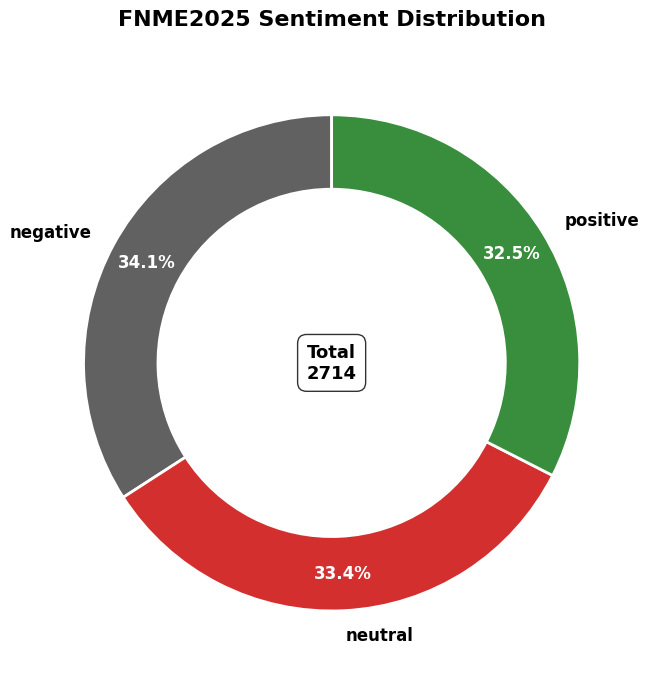

In [4]:
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11
})

colors = ['#616161', '#D32F2F', '#388E3C'] 

fig, ax = plt.subplots(1, 1, figsize=(9, 7))

# FNME2025
sentiment_counts_FNME2025 = FNME2025['sentiment'].value_counts()
wedges, texts, autotexts = ax.pie(
    sentiment_counts_FNME2025.values, 
    labels=sentiment_counts_FNME2025.index,
    autopct='%1.1f%%', 
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.3},
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    pctdistance=0.85
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

ax.set_title('FNME2025 Sentiment Distribution', fontsize=16, fontweight='bold', pad=20)

total_FNME2025 = FNME2025.shape[0]
ax.text(0, 0, f'Total\n{total_FNME2025}', 
         ha='center', va='center', 
         fontsize=13, fontweight='bold', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

plt.tight_layout()

plt.savefig('FNME2025_sentiment_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Evaluation Matrix

In [5]:
def evaluate_model(y_true, y_pred, y_pred_proba=None, average='macro'):

    results = {}

    results['Accuracy'] = accuracy_score(y_true, y_pred)
    results['Macro_Precision'] = precision_score(y_true, y_pred, average=average)
    results['Macro_Recall'] = recall_score(y_true, y_pred, average=average)
    results['Macro_F1'] = f1_score(y_true, y_pred, average=average)
    
    # Specificity
    cm = confusion_matrix(y_true, y_pred)
    specificity_scores = []
    for i in range(cm.shape[0]):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificity_scores.append(specificity)
    results['Macro_Specificity'] = np.mean(specificity_scores)
    
    # AUC & AUPRC
    if y_pred_proba is not None:
        try:
            # One-vs-Rest ROC AUC
            results['Macro_AUC'] = roc_auc_score(y_true, y_pred_proba, average=average, multi_class='ovr')
            # One-vs-Rest AUPRC
            results['Macro_AUPRC'] = average_precision_score(y_true, y_pred_proba, average=average)
        except:
            results['Macro_AUC'] = None
            results['Macro_AUPRC'] = None
    
    return results

In [6]:
from sklearn.metrics import roc_curve, auc

def save_roc_data_for_plotting(model_name, dataset_split, y_true, y_pred_proba, 
                              csv_filepath='roc2025_plotting_data.csv'):
    
    if dataset_split.lower() != 'test':
        return
    
    try:
        n_classes = y_pred_proba.shape[1]

        if n_classes == 3:
            class_names = ['negative', 'neutral', 'positive']  # 0, 1, 2
        else:
            class_names = [f'Class_{i}' for i in range(n_classes)]
        
        data_to_save = []
        
        for class_idx in range(n_classes):
            # One-vs-Rest
            y_true_binary = (y_true == class_idx).astype(int)
            y_score = y_pred_proba[:, class_idx]
            
            # ROC
            fpr, tpr, _ = roc_curve(y_true_binary, y_score)
            roc_auc = auc(fpr, tpr)
            
            for fp_rate, tp_rate in zip(fpr, tpr):
                data_to_save.append({
                    'model': model_name,
                    'class_index': class_idx,
                    'class_name': class_names[class_idx],
                    'fpr': fp_rate,
                    'tpr': tp_rate,
                    'auc': roc_auc
                })

        df_roc = pd.DataFrame(data_to_save)

        if not os.path.exists(csv_filepath):
            df_roc.to_csv(csv_filepath, index=False)
        else:
            df_roc.to_csv(csv_filepath, mode='a', header=False, index=False)
        
        print(f"[ROC Data Saving] Model '{model_name}' ROC data saved to {csv_filepath}")
        print(f"  Classes: {class_names}")
        print(f"  Data points: {len(df_roc)} rows")
        
    except Exception as e:
        print(f"[Warning] Failed to save ROC data for model '{model_name}': {e}")

# Baselines Current Performance

In [7]:
# ==================== TextCNN ====================
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, filter_sizes=[3, 4, 5], num_filters=100):
        super(TextCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.convs = nn.ModuleList([
            nn.Conv2d(1, num_filters, (fs, embed_dim)) for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(len(filter_sizes) * num_filters, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)
        x = x.unsqueeze(1)
        conv_results = []
        for conv in self.convs:
            conv_out = F.relu(conv(x)).squeeze(3)
            pool_out = F.max_pool1d(conv_out, conv_out.size(2)).squeeze(2)
            conv_results.append(pool_out)
        x = torch.cat(conv_results, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=100):
        if not isinstance(texts, list):
            if isinstance(texts, (pd.Series, np.ndarray)):
                texts = texts.tolist()
            else:
                texts = list(texts)
        
        if not isinstance(labels, list):
            if isinstance(labels, (pd.Series, np.ndarray)):
                labels = labels.tolist()
            else:
                labels = list(labels)
        
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        if isinstance(idx, (int, np.integer)):
            idx = int(idx)
            text = self.texts[idx]
            label = self.labels[idx]
            
            if isinstance(text, np.ndarray):
                try:
                    if text.ndim > 1:
                        text = ' '.join(str(x) for x in text.flatten())
                    else:
                        text = ' '.join(str(x) for x in text)
                except:
                    text = str(text)
            elif not isinstance(text, str):
                text = str(text)
            
            tokens = text.split()[:self.max_len]
            indices = [self.vocab.get(token, 0) for token in tokens]
            
            if len(indices) < self.max_len:
                indices += [0] * (self.max_len - len(indices))
            else:
                indices = indices[:self.max_len]
            
            return {
                'input_ids': torch.tensor(indices, dtype=torch.long),
                'labels': torch.tensor(label, dtype=torch.long)
            }

        if isinstance(idx, torch.Tensor):
            idx = idx.item()
            return self.__getitem__(idx)

        if isinstance(idx, (list, np.ndarray)):
            batch_result = {'input_ids': [], 'labels': []}
            for i in idx:
                if isinstance(i, torch.Tensor):
                    i = i.item()
                item = self.__getitem__(int(i))
                batch_result['input_ids'].append(item['input_ids'])
                batch_result['labels'].append(item['labels'])

            batch_result['input_ids'] = torch.stack(batch_result['input_ids'])
            batch_result['labels'] = torch.stack(batch_result['labels'])
            return batch_result

        idx = int(idx)
        return self.__getitem__(idx)

In [8]:
def evaluate_mlp_tfidf(model_path, texts, labels, model_save_path='/kaggle/working/FNME2025'):

    print(f"\n{'='*40}")
    print(f"Evaluating MLP+TF-IDF")
    print(f"{'='*40}")

    if not os.path.exists(model_path):
        print(f"❌ Model file not found: {model_path}")
        return None, None, None
    
    try:
        mlp_pipeline = joblib.load(model_path)
        print(f"✅ Loaded MLP+TF-IDF model from {model_path}")

        y_pred = mlp_pipeline.predict(texts)
        y_pred_proba = mlp_pipeline.predict_proba(texts)

        results = evaluate_model(labels, y_pred, y_pred_proba)
        print(f"\nMLP+TF-IDF Results on FNME2025:")
        for metric, value in results.items():
            if value is not None:
                if isinstance(value, (int, float)):
                    print(f"  {metric}: {value:.4f}")
                else:
                    print(f"  {metric}: {value}")

        save_roc_data_for_plotting(
            model_name="mlp_tfidf",
            dataset_split='test',
            y_true=labels,
            y_pred_proba=y_pred_proba,
            csv_filepath=os.path.join(model_save_path, 'all2025_models_roc_data.csv')
        )
        
        return y_pred, y_pred_proba, results
        
    except Exception as e:
        print(f"❌ Error evaluating MLP+TF-IDF: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None, None

def evaluate_textcnn(model_path, texts, labels, model_save_path='/kaggle/working/FNME2025'):
    print(f"\n{'='*40}")
    print(f"Evaluating TextCNN")
    print(f"{'='*40}")
    
    if not os.path.exists(model_path):
        print(f"❌ Model file not found: {model_path}")
        return None, None, None
    
    try:
        import torch.serialization

        try:
            torch.serialization.add_safe_globals([CountVectorizer])

            checkpoint = torch.load(model_path, map_location='cpu', weights_only=True)
        except:
            print("⚠️ Using weights_only=False (trusted source required)")
            checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)

        
        vocab = checkpoint.get('vocab', {})
        vectorizer = checkpoint.get('vectorizer', None)
        vocab_size = checkpoint.get('vocab_size', len(vocab) + 1)

        model = TextCNN(vocab_size, 100, 3)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()
        print(f"✅ Loaded TextCNN model from {model_path}")

        def text_to_indices(text, vocab, max_len=100):
            tokens = str(text).split()[:max_len]
            indices = [vocab.get(token, 0) for token in tokens]
            if len(indices) < max_len:
                indices += [0] * (max_len - len(indices))
            return indices[:max_len]

        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model.to(device)
        
        batch_size = 32
        all_probs = []
        
        with torch.no_grad():
            for i in range(0, len(texts), batch_size):
                batch_texts = texts[i:i+batch_size]
                batch_indices = [text_to_indices(text, vocab) for text in batch_texts]
                batch_tensor = torch.tensor(batch_indices, dtype=torch.long).to(device)
                
                outputs = model(batch_tensor)
                probs = F.softmax(outputs, dim=1)
                all_probs.append(probs.cpu().numpy())
        
        all_probs = np.vstack(all_probs)
        y_pred = np.argmax(all_probs, axis=1)

        results = evaluate_model(labels, y_pred, all_probs)
        print(f"\nTextCNN Results on FNME2025:")
        for metric, value in results.items():
            if value is not None:
                if isinstance(value, (int, float)):
                    print(f"  {metric}: {value:.4f}")
                else:
                    print(f"  {metric}: {value}")

        save_roc_data_for_plotting(
            model_name="textcnn",
            dataset_split='test',
            y_true=labels,
            y_pred_proba=all_probs,
            csv_filepath=os.path.join(model_save_path, 'all2025_models_roc_data.csv')
        )
        
        return y_pred, all_probs, results
        
    except Exception as e:
        print(f"❌ Error evaluating TextCNN: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None, None

def evaluate_bert_model(model_dir, texts, labels, model_name, model_save_path='/kaggle/working/FNME2025'):
    print(f"\n{'='*40}")
    print(f"Evaluating {model_name.upper()}")
    print(f"{'='*40}")
    
    if not os.path.exists(model_dir):
        print(f"❌ Model directory not found: {model_dir}")
        return None, None, None
    
    try:
        model_files = ['pytorch_model.bin', 'model.safetensors', 'pytorch_model.bin.index.json']
        has_model_file = any(os.path.exists(os.path.join(model_dir, f)) for f in model_files)
        
        if not has_model_file and not os.path.exists(os.path.join(model_dir, 'config.json')):
            print(f"❌ Model files not found in {model_dir}")
            return None, None, None

        tokenizer = AutoTokenizer.from_pretrained(model_dir)
        model = AutoModelForSequenceClassification.from_pretrained(model_dir)

        config_path = os.path.join(model_dir, 'config.json')
        if os.path.exists(config_path):
            with open(config_path, 'r') as f:
                config = json.load(f)
            num_labels = config.get('num_labels', 3)
        else:
            num_labels = 3
            
        print(f"✅ Loaded {model_name.upper()} model with {num_labels} classes")

        def tokenize_function(examples):
            return tokenizer(examples['text'], truncation=True, max_length=128, padding='max_length')

        eval_data = pd.DataFrame({'text': texts, 'label': labels})
        eval_dataset = Dataset.from_pandas(eval_data)
        eval_dataset = eval_dataset.map(tokenize_function, batched=True)
        eval_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

        data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

        training_args = TrainingArguments(
            output_dir=f"./temp_eval_{os.getpid()}",
            per_device_eval_batch_size=16,
            report_to="none",
            remove_unused_columns=False,
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            data_collator=data_collator,
        )

        predictions = trainer.predict(eval_dataset)
        y_pred = np.argmax(predictions.predictions, axis=-1)
        y_pred_proba = F.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()

        results = evaluate_model(labels, y_pred, y_pred_proba)
        print(f"\n{model_name.upper()} Results on FNME2025:")
        for metric, value in results.items():
            if value is not None:
                if isinstance(value, (int, float)):
                    print(f"  {metric}: {value:.4f}")
                else:
                    print(f"  {metric}: {value}")

        save_roc_data_for_plotting(
            model_name=model_name.lower(),
            dataset_split='test',
            y_true=labels,
            y_pred_proba=y_pred_proba,
            csv_filepath=os.path.join(model_save_path, 'all2025_models_roc_data.csv')
        )

        temp_dir = f"./temp_eval_{os.getpid()}"
        if os.path.exists(temp_dir):
            shutil.rmtree(temp_dir)
        
        return y_pred, y_pred_proba, results
        
    except Exception as e:
        print(f"❌ Error evaluating {model_name}: {str(e)}")
        import traceback
        traceback.print_exc()

        temp_dir = f"./temp_eval_{os.getpid()}"
        if os.path.exists(temp_dir):
            shutil.rmtree(temp_dir)
        
        return None, None, None

In [9]:
def evaluate_qwen2_model(model_dir, texts, labels, model_name, model_save_path='/kaggle/working/FNME2025'):
    print(f"\n{'='*40}")
    print(f"Evaluating {model_name.upper()}")
    print(f"{'='*40}")
    
    if not os.path.exists(model_dir):
        print(f"❌ Model directory not found: {model_dir}")
        return None, None, None
    
    try:
        print(f"Checking qwen2 directory: {model_dir}")
        files_in_dir = os.listdir(model_dir)
        print(f"Files in qwen2 directory: {files_in_dir}")

        try:
            tokenizer = AutoTokenizer.from_pretrained(model_dir, trust_remote_code=True)
        except Exception as e:
            print(f"⚠️ Error loading tokenizer: {e}")

            try:
                tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2-1.5B-Instruct", trust_remote_code=True)
                print("✅ Loaded tokenizer from base model")
            except:
                print("❌ Could not load any tokenizer")
                return None, None, None

        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token

        from transformers import AutoModelForCausalLM
        import torch.nn as nn

        base_model_paths = [
            "/kaggle/input/models/qwen-lm/qwen2/transformers/1.5b-instruct/1",
            "Qwen/Qwen2-1.5B-Instruct",
            "Qwen/Qwen2-1.5B",
        ]
        
        base_model = None
        for path in base_model_paths:
            try:
                if os.path.exists(path):
                    print(f"Trying to load base model from: {path}")
                    base_model = AutoModelForCausalLM.from_pretrained(
                        path, 
                        trust_remote_code=True,
                        torch_dtype=torch.float32
                    )
                    print(f"✅ Loaded base model from: {path}")
                    break
                else:
                    print(f"Trying to load from huggingface: {path}")
                    base_model = AutoModelForCausalLM.from_pretrained(
                        path, 
                        trust_remote_code=True,
                        torch_dtype=torch.float32
                    )
                    print(f"✅ Loaded base model from huggingface: {path}")
                    break
            except Exception as e:
                print(f"Failed to load from {path}: {e}")
                continue
        
        if base_model is None:
            print("❌ Could not load base Qwen2 model")
            return None, None, None

        config_path = os.path.join(model_dir, 'config.json')
        num_labels = 3
        if os.path.exists(config_path):
            with open(config_path, 'r') as f:
                config = json.load(f)
            num_labels = config.get('num_labels', 3)
            print(f"Loaded config: num_labels={num_labels}")
        else:
            print("⚠️ config.json not found, using default num_labels=3")

        class Qwen2Classifier(nn.Module):
            def __init__(self, base_model, num_labels):
                super().__init__()
                self.qwen2 = base_model
                for param in self.qwen2.parameters():
                    param.requires_grad = False
                
                hidden_size = self.qwen2.config.hidden_size
                self.classifier = nn.Sequential(
                    nn.Dropout(0.1),
                    nn.Linear(hidden_size, 128), 
                    nn.ReLU(),
                    nn.Dropout(0.1),
                    nn.Linear(128, num_labels)
                )
            
            def forward(self, input_ids, attention_mask=None, labels=None):
                with torch.no_grad():
                    outputs = self.qwen2(
                        input_ids=input_ids,
                        attention_mask=attention_mask,
                        output_hidden_states=True
                    )
                
                hidden_states = outputs.hidden_states[-1]
                last_token_hidden = hidden_states[:, -1, :]
                logits = self.classifier(last_token_hidden)
                
                loss = None
                if labels is not None:
                    loss_fct = nn.CrossEntropyLoss()
                    loss = loss_fct(logits.view(-1, self.classifier[-1].out_features), labels.view(-1))
                
                return (loss, logits) if loss is not None else logits

        model = Qwen2Classifier(base_model, num_labels)

        classifier_weights_path = os.path.join(model_dir, 'classifier.pth')
        if os.path.exists(classifier_weights_path):
            print(f"Loading classifier weights from: {classifier_weights_path}")
            classifier_state_dict = torch.load(classifier_weights_path, map_location='cpu')
            model.classifier.load_state_dict(classifier_state_dict)
            print("✅ Loaded classifier weights successfully")
        else:
            print("⚠️ classifier.pth not found, checking for other model files...")
            model_files = ['pytorch_model.bin', 'model.safetensors']
            for file in model_files:
                if os.path.exists(os.path.join(model_dir, file)):
                    print(f"Found model file: {file}")
                    break

        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model.to(device)
        model.eval()
        
        print(f"✅ Loaded {model_name.upper()} model successfully")
        print(f"Model device: {device}")

        def tokenize_function(examples):
            return tokenizer(
                examples['text'], 
                truncation=True, 
                max_length=32,  
                padding='max_length',
                return_tensors="pt"
            )
        
        eval_data = pd.DataFrame({'text': texts, 'label': labels})
        eval_dataset = Dataset.from_pandas(eval_data)
        eval_dataset = eval_dataset.map(tokenize_function, batched=True)
        eval_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

        batch_size = 8
        all_preds = []
        all_probs = []
        
        print(f"Starting inference on {len(eval_dataset)} samples...")
        
        with torch.no_grad():
            for i in range(0, len(eval_dataset), batch_size):
                batch = eval_dataset[i:i+batch_size]
                
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
   
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                
                if isinstance(outputs, tuple):
                    logits = outputs[1]  
                else:
                    logits = outputs
                
                probs = torch.softmax(logits, dim=-1)
                preds = torch.argmax(logits, dim=-1)
                
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
 
                if (i // batch_size) % 10 == 0 or i + batch_size >= len(eval_dataset):
                    print(f"  Processed {min(i+batch_size, len(eval_dataset))}/{len(eval_dataset)} samples")
        
        y_pred = np.array(all_preds)
        y_pred_proba = np.array(all_probs)
        
        print(f"✅ Inference completed")
        print(f"Predictions shape: {y_pred.shape}")
        print(f"Probabilities shape: {y_pred_proba.shape}")

        results = evaluate_model(labels, y_pred, y_pred_proba)
        print(f"\n{model_name.upper()} Results on FNME2025:")
        for metric, value in results.items():
            if value is not None:
                if isinstance(value, (int, float)):
                    print(f"  {metric}: {value:.4f}")
                else:
                    print(f"  {metric}: {value}")
        
        if 'save_roc_data_for_plotting' in globals():
            save_roc_data_for_plotting(
                model_name=model_name.lower(),
                dataset_split='test',
                y_true=labels,
                y_pred_proba=y_pred_proba,
                csv_filepath=os.path.join(model_save_path, 'all2025_models_roc_data.csv')
            )
            print(f"✅ Saved ROC data")
        
        return y_pred, y_pred_proba, results
        
    except Exception as e:
        print(f"❌ Error evaluating {model_name}: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None, None

In [10]:
def evaluate_all_models_on_FNME2025(FNME2025_df, base_model_path, output_path='/kaggle/working/FNME2025', qwen2_model_path=None):
    
    print("="*40)
    print("Preparing FNME2025 dataset for evaluation")
    print("="*40)

    if 'label' not in FNME2025_df.columns or 'title' not in FNME2025_df.columns:
        print("❌ Dataset must contain 'label' and 'title' columns")
        return
    
    texts = FNME2025_df['title'].astype(str).tolist()
    labels = FNME2025_df['label'].astype(int).values
    
    print(f"Dataset size: {len(FNME2025_df)}")
    print(f"Label distribution:")
    for label_val, label_name in [(0, 'negative'), (1, 'neutral'), (2, 'positive')]:
        count = (labels == label_val).sum()
        print(f"  {label_name}: {count} ({count/len(labels)*100:.1f}%)")

    os.makedirs(output_path, exist_ok=True)

    if qwen2_model_path is None:
        print("⚠️ No qwen2_model_path provided, trying to find qwen2 in base_model_path...")
        potential_qwen2_dir = os.path.join(base_model_path, "qwen2")
        if os.path.exists(potential_qwen2_dir):
            qwen2_model_path = base_model_path
            print(f"✅ Found qwen2 in base_model_path: {qwen2_model_path}")

    models_to_evaluate = [
        ("mlp_tfidf", base_model_path, ""),  
        ("textcnn", base_model_path, ""),   
        ("bert", base_model_path, ""),        
        ("roberta", base_model_path, ""),     
        ("finbert", base_model_path, ""),     
    ]
    
    if qwen2_model_path is not None:
        models_to_evaluate.append(("qwen2", qwen2_model_path, ""))
        print(f"✅ Will evaluate qwen2 model from: {qwen2_model_path}")
    
    all_results = {}
    
    for model_name, model_path, model_file in models_to_evaluate:
        print(f"\n{'='*40}")
        print(f"Processing: {model_name}")
        print(f"{'='*40}")
        
        if model_path is None:
            print(f"⚠️ No model path provided for {model_name}")
            continue
            
        if model_name in ["mlp_tfidf", "textcnn"]:
            extension = ".pkl" if model_name == "mlp_tfidf" else ".pth"
            full_model_path = os.path.join(model_path, f"{model_name}{extension}")
            
            print(f"Looking for file: {full_model_path}")
            
            if not os.path.exists(full_model_path):
                print(f"⚠️ Model file not found: {full_model_path}")
                all_files = os.listdir(model_path)
                matching_files = [f for f in all_files if model_name in f]
                if matching_files:
                    print(f"  Found similar files: {matching_files}")
                continue

            if model_name == "mlp_tfidf":
                y_pred, y_pred_proba, results = evaluate_mlp_tfidf(
                    full_model_path, texts, labels, output_path
                )
            elif model_name == "textcnn":
                y_pred, y_pred_proba, results = evaluate_textcnn(
                    full_model_path, texts, labels, output_path
                )
                
        elif model_name == "qwen2":
            model_dir = os.path.join(model_path, "qwen2")
            print(f"Looking for qwen2 directory: {model_dir}")
            
            if not os.path.exists(model_dir):
                print(f"⚠️ Qwen2 model directory not found: {model_dir}")
                print(f"  Checking for alternative qwen2 paths...")

                possible_paths = [
                    model_path,
                    os.path.join(model_path, "qwen2-1.5B"),
                    os.path.join(model_path, "qwen2_1.5b"),
                ]
                
                found = False
                for alt_path in possible_paths:
                    if os.path.exists(alt_path):
                        model_dir = alt_path
                        print(f"✅ Found qwen2 at: {model_dir}")
                        found = True
                        break
                
                if not found:
                    print(f"❌ Could not find qwen2 model directory")
                    continue

            y_pred, y_pred_proba, results = evaluate_qwen2_model(
                model_dir, texts, labels, model_name, output_path
            )
            
        else:  # bert, roberta, finbert
            model_dir = os.path.join(model_path, model_name)
            print(f"Looking for directory: {model_dir}")
            
            if not os.path.exists(model_dir):
                print(f"⚠️ Model directory not found: {model_dir}")
                continue

            y_pred, y_pred_proba, results = evaluate_bert_model(
                model_dir, texts, labels, model_name, output_path
            )
        
        if results is not None:
            all_results[model_name] = results
            print(f"✅ Successfully evaluated {model_name}")
        else:
            print(f"❌ Failed to evaluate {model_name}")

    print("\n" + "="*40)
    print("SUMMARY OF ALL MODELS ON FNME2025")
    print("="*40)
    
    if all_results:
        results_df = pd.DataFrame(all_results).T

        metric_order = ['Accuracy', 'Macro_Precision', 'Macro_Recall', 'Macro_F1', 
                       'Macro_Specificity', 'Macro_AUC', 'Macro_AUPRC']

        existing_metrics = [m for m in metric_order if m in results_df.columns]
        if existing_metrics:
            results_df = results_df[existing_metrics]
        
        print("\nDetailed Results:")

        def format_value(x):
            if x is None:
                return "N/A"
            elif isinstance(x, (int, float)):
                return f"{x:.4f}"
            else:
                return str(x)
        
        print(results_df.to_string(formatters={col: format_value for col in results_df.columns}))

        results_csv_path = os.path.join(output_path, 'model2025_results.csv')
        results_df.to_csv(results_csv_path)
        print(f"\nResults saved to: {results_csv_path}")

        if 'Accuracy' in results_df.columns:
            best_model = results_df['Accuracy'].idxmax()
            best_accuracy = results_df.loc[best_model, 'Accuracy']
            print(f"\n🏆 Best model: {best_model} (Accuracy: {best_accuracy:.4f})")

    else:
        print("❌ No models were successfully evaluated")
    
    print("\n" + "="*40)
    print("Evaluation completed!")
    print("="*40)

# def evaluate_all_models_on_FNME2025(FNME2025_df, base_model_path, output_path='/kaggle/working/FNME2025'):
    
#     print("="*40)
#     print("Preparing FNME2025 dataset for evaluation")
#     print("="*40)

#     if 'label' not in FNME2025_df.columns or 'title' not in FNME2025_df.columns:
#         print("❌ Dataset must contain 'label' and 'title' columns")
#         return
    
#     texts = FNME2025_df['title'].astype(str).tolist()
#     labels = FNME2025_df['label'].astype(int).values
    
#     print(f"Dataset size: {len(FNME2025_df)}")
#     print(f"Label distribution:")
#     for label_val, label_name in [(0, 'negative'), (1, 'neutral'), (2, 'positive')]:
#         count = (labels == label_val).sum()
#         print(f"  {label_name}: {count} ({count/len(labels)*100:.1f}%)")

#     os.makedirs(output_path, exist_ok=True)

#     models_to_evaluate = [
#         ("mlp_tfidf", ""), 
#         ("textcnn", ""), 
#         ("bert", ""),
#         ("roberta", ""),
#         ("finbert", "")
#     ]
    
#     all_results = {}

    
#     for model_name, model_file in models_to_evaluate:
#         print(f"\n{'='*40}")
#         print(f"Processing: {model_name}")
#         print(f"{'='*40}")
        
#         if model_name in ["mlp_tfidf", "textcnn"]:
#             extension = ".pkl" if model_name == "mlp_tfidf" else ".pth"
#             model_path = os.path.join(base_model_path, f"{model_name}{extension}")
            
#             print(f"Looking for file: {model_path}")
            
#             if not os.path.exists(model_path):
#                 print(f"⚠️ Model file not found: {model_path}")
#                 all_files = os.listdir(base_model_path)
#                 matching_files = [f for f in all_files if model_name in f]
#                 if matching_files:
#                     print(f"  Found similar files: {matching_files}")
#                 continue

#             if model_name == "mlp_tfidf":
#                 y_pred, y_pred_proba, results = evaluate_mlp_tfidf(
#                     model_path, texts, labels, output_path
#                 )
#             elif model_name == "textcnn":
#                 y_pred, y_pred_proba, results = evaluate_textcnn(
#                     model_path, texts, labels, output_path
#                 )
                
#         else:
#             model_dir = os.path.join(base_model_path, model_name)
#             print(f"Looking for directory: {model_dir}")
            
#             if not os.path.exists(model_dir):
#                 print(f"⚠️ Model directory not found: {model_dir}")
#                 continue

#             y_pred, y_pred_proba, results = evaluate_bert_model(
#                 model_dir, texts, labels, model_name, output_path
#             )
        
#         if results is not None:
#             all_results[model_name] = results
#         else:
#             print(f"❌ Failed to evaluate {model_name}")

#     print("\n" + "="*40)
#     print("SUMMARY OF ALL MODELS ON FNME2025")
#     print("="*40)
    
#     if all_results:
#         results_df = pd.DataFrame(all_results).T

#         metric_order = ['Accuracy', 'Macro_Precision', 'Macro_Recall', 'Macro_F1', 
#                        'Macro_Specificity', 'Macro_AUC', 'Macro_AUPRC']

#         existing_metrics = [m for m in metric_order if m in results_df.columns]
#         if existing_metrics:
#             results_df = results_df[existing_metrics]
        
#         print("\nDetailed Results:")

#         def format_value(x):
#             if x is None:
#                 return "N/A"
#             elif isinstance(x, (int, float)):
#                 return f"{x:.4f}"
#             else:
#                 return str(x)
        
#         print(results_df.to_string(formatters={col: format_value for col in results_df.columns}))

#         results_csv_path = os.path.join(output_path, 'model2025_results.csv')
#         results_df.to_csv(results_csv_path)
#         print(f"\nResults saved to: {results_csv_path}")
        

#     else:
#         print("❌ No models were successfully evaluated")
    
#     print("\n" + "="*40)
#     print("Evaluation completed!")
#     print("="*40)

In [11]:
base_model_path = "/kaggle/input/notebooks/nicolesy/exp-1-baselines-performance/SAFN"
qwen2_path = "/kaggle/input/notebooks/nicolesy/exp-1-qwen2-all-baselines/SAFN"
output_path = "/kaggle/working/FNME_SAFN"
evaluate_all_models_on_FNME2025(FNME2025, base_model_path, output_path, qwen2_path)

# base_model_path = "/kaggle/input/notebooks/nicolesy/exp-1-baselines-performance/SAFN"
# output_path = "/kaggle/working/FNME_SAFN"
# evaluate_all_models_on_FNME2025(FNME2025, base_model_path, output_path)

Preparing FNME2025 dataset for evaluation
Dataset size: 2714
Label distribution:
  negative: 926 (34.1%)
  neutral: 906 (33.4%)
  positive: 882 (32.5%)
✅ Will evaluate qwen2 model from: /kaggle/input/notebooks/nicolesy/exp-1-qwen2-all-baselines/SAFN

Processing: mlp_tfidf
Looking for file: /kaggle/input/notebooks/nicolesy/exp-1-baselines-performance/SAFN/mlp_tfidf.pkl

Evaluating MLP+TF-IDF
✅ Loaded MLP+TF-IDF model from /kaggle/input/notebooks/nicolesy/exp-1-baselines-performance/SAFN/mlp_tfidf.pkl

MLP+TF-IDF Results on FNME2025:
  Accuracy: 0.3312
  Macro_Precision: 0.3351
  Macro_Recall: 0.3326
  Macro_F1: 0.3100
  Macro_Specificity: 0.6664
  Macro_AUC: 0.5045
  Macro_AUPRC: 0.3361
[ROC Data Saving] Model 'mlp_tfidf' ROC data saved to /kaggle/working/FNME_SAFN/all2025_models_roc_data.csv
  Classes: ['negative', 'neutral', 'positive']
  Data points: 153 rows
✅ Successfully evaluated mlp_tfidf

Processing: textcnn
Looking for file: /kaggle/input/notebooks/nicolesy/exp-1-baselines-per

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Loaded BERT model with 3 classes


Map:   0%|          | 0/2714 [00:00<?, ? examples/s]


BERT Results on FNME2025:
  Accuracy: 0.3320
  Macro_Precision: 0.3309
  Macro_Recall: 0.3312
  Macro_F1: 0.3219
  Macro_Specificity: 0.6656
  Macro_AUC: 0.4964
  Macro_AUPRC: 0.3297
[ROC Data Saving] Model 'bert' ROC data saved to /kaggle/working/FNME_SAFN/all2025_models_roc_data.csv
  Classes: ['negative', 'neutral', 'positive']
  Data points: 200 rows
✅ Successfully evaluated bert

Processing: roberta
Looking for directory: /kaggle/input/notebooks/nicolesy/exp-1-baselines-performance/SAFN/roberta

Evaluating ROBERTA


...

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✅ Loaded base model from huggingface: Qwen/Qwen2-1.5B-Instruct
Loaded config: num_labels=3
Loading classifier weights from: /kaggle/input/notebooks/nicolesy/exp-1-qwen2-all-baselines/SAFN/qwen2/classifier.pth
✅ Loaded classifier weights successfully
✅ Loaded QWEN2 model successfully
Model device: cuda


Map:   0%|          | 0/2714 [00:00<?, ? examples/s]

Starting inference on 2714 samples...
  Processed 8/2714 samples
  Processed 88/2714 samples
  Processed 168/2714 samples
  Processed 248/2714 samples
  Processed 328/2714 samples
  Processed 408/2714 samples
  Processed 488/2714 samples
  Processed 568/2714 samples
  Processed 648/2714 samples
  Processed 728/2714 samples
  Processed 808/2714 samples
  Processed 888/2714 samples
  Processed 968/2714 samples
  Processed 1048/2714 samples
  Processed 1128/2714 samples
  Processed 1208/2714 samples
  Processed 1288/2714 samples
  Processed 1368/2714 samples
  Processed 1448/2714 samples
  Processed 1528/2714 samples
  Processed 1608/2714 samples
  Processed 1688/2714 samples
  Processed 1768/2714 samples
  Processed 1848/2714 samples
  Processed 1928/2714 samples
  Processed 2008/2714 samples
  Processed 2088/2714 samples
  Processed 2168/2714 samples
  Processed 2248/2714 samples
  Processed 2328/2714 samples
  Processed 2408/2714 samples
  Processed 2488/2714 samples
  Processed 2568/2

In [12]:
base_model_path = "/kaggle/input/notebooks/nicolesy/exp-1-baselines-performance/SEntFiN"
qwen2_path = "/kaggle/input/notebooks/nicolesy/exp-1-qwen2-all-baselines/SEntFiN"
output_path = "/kaggle/working/FNME_SEntFiN"
evaluate_all_models_on_FNME2025(FNME2025, base_model_path, output_path, qwen2_path)

# base_model_path = "/kaggle/input/notebooks/nicolesy/exp-1-baselines-performance/SEntFiN"
# output_path = "/kaggle/working/FNME_SEntFiN"
# evaluate_all_models_on_FNME2025(FNME2025, base_model_path, output_path)

Preparing FNME2025 dataset for evaluation
Dataset size: 2714
Label distribution:
  negative: 926 (34.1%)
  neutral: 906 (33.4%)
  positive: 882 (32.5%)
✅ Will evaluate qwen2 model from: /kaggle/input/notebooks/nicolesy/exp-1-qwen2-all-baselines/SEntFiN

Processing: mlp_tfidf
Looking for file: /kaggle/input/notebooks/nicolesy/exp-1-baselines-performance/SEntFiN/mlp_tfidf.pkl

Evaluating MLP+TF-IDF
✅ Loaded MLP+TF-IDF model from /kaggle/input/notebooks/nicolesy/exp-1-baselines-performance/SEntFiN/mlp_tfidf.pkl

MLP+TF-IDF Results on FNME2025:
  Accuracy: 0.3346
  Macro_Precision: 0.3428
  Macro_Recall: 0.3367
  Macro_F1: 0.3170
  Macro_Specificity: 0.6685
  Macro_AUC: 0.4974
  Macro_AUPRC: 0.3335
[ROC Data Saving] Model 'mlp_tfidf' ROC data saved to /kaggle/working/FNME_SEntFiN/all2025_models_roc_data.csv
  Classes: ['negative', 'neutral', 'positive']
  Data points: 151 rows
✅ Successfully evaluated mlp_tfidf

Processing: textcnn
Looking for file: /kaggle/input/notebooks/nicolesy/exp-1-b

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Loaded BERT model with 3 classes


Map:   0%|          | 0/2714 [00:00<?, ? examples/s]


BERT Results on FNME2025:
  Accuracy: 0.3312
  Macro_Precision: 0.3353
  Macro_Recall: 0.3313
  Macro_F1: 0.3211
  Macro_Specificity: 0.6657
  Macro_AUC: 0.5026
  Macro_AUPRC: 0.3353
[ROC Data Saving] Model 'bert' ROC data saved to /kaggle/working/FNME_SEntFiN/all2025_models_roc_data.csv
  Classes: ['negative', 'neutral', 'positive']
  Data points: 200 rows
✅ Successfully evaluated bert

Processing: roberta
Looking for directory: /kaggle/input/notebooks/nicolesy/exp-1-baselines-performance/SEntFiN/roberta

Evaluating ROBERTA


...

Trying to load from huggingface: /kaggle/input/models/qwen-lm/qwen2/transformers/1.5b-instruct/1
Failed to load from /kaggle/input/models/qwen-lm/qwen2/transformers/1.5b-instruct/1: Repo id must be in the form 'repo_name' or 'namespace/repo_name': '/kaggle/input/models/qwen-lm/qwen2/transformers/1.5b-instruct/1'. Use `repo_type` argument if needed.
Trying to load from huggingface: Qwen/Qwen2-1.5B-Instruct


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

✅ Loaded base model from huggingface: Qwen/Qwen2-1.5B-Instruct
Loaded config: num_labels=3
Loading classifier weights from: /kaggle/input/notebooks/nicolesy/exp-1-qwen2-all-baselines/SEntFiN/qwen2/classifier.pth
✅ Loaded classifier weights successfully
✅ Loaded QWEN2 model successfully
Model device: cuda


Map:   0%|          | 0/2714 [00:00<?, ? examples/s]

Starting inference on 2714 samples...
  Processed 8/2714 samples
  Processed 88/2714 samples
  Processed 168/2714 samples
  Processed 248/2714 samples
  Processed 328/2714 samples
  Processed 408/2714 samples
  Processed 488/2714 samples
  Processed 568/2714 samples
  Processed 648/2714 samples
  Processed 728/2714 samples
  Processed 808/2714 samples
  Processed 888/2714 samples
  Processed 968/2714 samples
  Processed 1048/2714 samples
  Processed 1128/2714 samples
  Processed 1208/2714 samples
  Processed 1288/2714 samples
  Processed 1368/2714 samples
  Processed 1448/2714 samples
  Processed 1528/2714 samples
  Processed 1608/2714 samples
  Processed 1688/2714 samples
  Processed 1768/2714 samples
  Processed 1848/2714 samples
  Processed 1928/2714 samples
  Processed 2008/2714 samples
  Processed 2088/2714 samples
  Processed 2168/2714 samples
  Processed 2248/2714 samples
  Processed 2328/2714 samples
  Processed 2408/2714 samples
  Processed 2488/2714 samples
  Processed 2568/2

# Baseline Past Performance

In [13]:
past_results_data = {
    'mlp_tfidf': {
        'Accuracy': 0.6795,
        'Macro_Precision': 0.6124,
        'Macro_Recall': 0.6125,
        'Macro_F1': 0.6122,
        'Macro_Specificity': 0.8068,
        'Macro_AUC': 0.8160,
        'Macro_AUPRC': 0.6928
    },
    'textcnn': {
        'Accuracy': 0.7414,
        'Macro_Precision': 0.7064,
        'Macro_Recall': 0.6612,
        'Macro_F1': 0.6757,
        'Macro_Specificity': 0.8264,
        'Macro_AUC': 0.8387,
        'Macro_AUPRC': 0.7374
    },
    'bert': {
        'Accuracy': 0.8322,
        'Macro_Precision': 0.7930,
        'Macro_Recall': 0.8402,
        'Macro_F1': 0.8127,
        'Macro_Specificity': 0.9058,
        'Macro_AUC': 0.9431,
        'Macro_AUPRC': 0.8863
    },
    'roberta': {
        'Accuracy': 0.8446,
        'Macro_Precision': 0.8105,
        'Macro_Recall': 0.8639,
        'Macro_F1': 0.8328,
        'Macro_Specificity': 0.9135,
        'Macro_AUC': 0.9572,
        'Macro_AUPRC': 0.9254
    },
    'finbert': {
        'Accuracy': 0.8391,
        'Macro_Precision': 0.8057,
        'Macro_Recall': 0.8466,
        'Macro_F1': 0.8233,
        'Macro_Specificity': 0.9070,
        'Macro_AUC': 0.9257,
        'Macro_AUPRC': 0.8633
    },
    'qwen2': {
        'Accuracy': 0.5722,
        'Macro_Precision': 0.4503,
        'Macro_Recall': 0.3728,
        'Macro_F1': 0.3562,
        'Macro_Specificity': 0.6989,
        'Macro_AUC': 0.6204,
        'Macro_AUPRC': 0.4212
    }
}

past_results_df = pd.DataFrame(past_results_data).T

column_order = ['Accuracy', 'Macro_Precision', 'Macro_Recall', 'Macro_F1', 
                'Macro_Specificity', 'Macro_AUC', 'Macro_AUPRC']
past_results_df = past_results_df[column_order]

save_path = "/kaggle/working/FNME_SAFN/modelPast_results.csv"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
past_results_df.to_csv(save_path)

print("Detailed Results:")
print(past_results_df.to_string(float_format=lambda x: f"{x:.4f}"))
print(f"\nResults saved to: {save_path}")
print(f"Shape: {past_results_df.shape}")

Detailed Results:
           Accuracy  Macro_Precision  Macro_Recall  Macro_F1  Macro_Specificity  Macro_AUC  Macro_AUPRC
mlp_tfidf    0.6795           0.6124        0.6125    0.6122             0.8068     0.8160       0.6928
textcnn      0.7414           0.7064        0.6612    0.6757             0.8264     0.8387       0.7374
bert         0.8322           0.7930        0.8402    0.8127             0.9058     0.9431       0.8863
roberta      0.8446           0.8105        0.8639    0.8328             0.9135     0.9572       0.9254
finbert      0.8391           0.8057        0.8466    0.8233             0.9070     0.9257       0.8633
qwen2        0.5722           0.4503        0.3728    0.3562             0.6989     0.6204       0.4212

Results saved to: /kaggle/working/FNME_SAFN/modelPast_results.csv
Shape: (6, 7)


In [14]:
past_results_data = {
    'mlp_tfidf': {
        'Accuracy': 0.7223,
        'Macro_Precision': 0.7163,
        'Macro_Recall': 0.7114,
        'Macro_F1': 0.7135,
        'Macro_Specificity': 0.8575,
        'Macro_AUC': 0.8728,
        'Macro_AUPRC': 0.7949
    },
    'textcnn': {
        'Accuracy': 0.7099,
        'Macro_Precision': 0.7225,
        'Macro_Recall': 0.6967,
        'Macro_F1': 0.7057,
        'Macro_Specificity': 0.8458,
        'Macro_AUC': 0.8507,
        'Macro_AUPRC': 0.7646
    },
    'bert': {
        'Accuracy': 0.7991,
        'Macro_Precision': 0.7957,
        'Macro_Recall': 0.8082,
        'Macro_F1': 0.8002,
        'Macro_Specificity': 0.8987,
        'Macro_AUC': 0.9257,
        'Macro_AUPRC': 0.8737
    },
    'roberta': {
        'Accuracy': 0.8543,
        'Macro_Precision': 0.8539,
        'Macro_Recall': 0.8554,
        'Macro_F1': 0.8546,
        'Macro_Specificity': 0.9248,
        'Macro_AUC': 0.9581,
        'Macro_AUPRC': 0.9286
    },
    'finbert': {
        'Accuracy': 0.8165,
        'Macro_Precision': 0.8142,
        'Macro_Recall': 0.8241,
        'Macro_F1': 0.8174,
        'Macro_Specificity': 0.9074,
        'Macro_AUC': 0.9436,
        'Macro_AUPRC': 0.9059
    },
    'qwen2': {
        'Accuracy': 0.4867,
        'Macro_Precision': 0.4682,
        'Macro_Recall': 0.4454,
        'Macro_F1': 0.4402,
        'Macro_Specificity': 0.7267,
        'Macro_AUC': 0.6531,
        'Macro_AUPRC': 0.4844
    }
}

past_results_df = pd.DataFrame(past_results_data).T

column_order = ['Accuracy', 'Macro_Precision', 'Macro_Recall', 'Macro_F1', 
                'Macro_Specificity', 'Macro_AUC', 'Macro_AUPRC']
past_results_df = past_results_df[column_order]

save_path = "/kaggle/working/FNME_SEntFiN/modelPast_results.csv"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
past_results_df.to_csv(save_path)

print("Detailed Results:")
print(past_results_df.to_string(float_format=lambda x: f"{x:.4f}"))
print(f"\nResults saved to: {save_path}")
print(f"Shape: {past_results_df.shape}")

Detailed Results:
           Accuracy  Macro_Precision  Macro_Recall  Macro_F1  Macro_Specificity  Macro_AUC  Macro_AUPRC
mlp_tfidf    0.7223           0.7163        0.7114    0.7135             0.8575     0.8728       0.7949
textcnn      0.7099           0.7225        0.6967    0.7057             0.8458     0.8507       0.7646
bert         0.7991           0.7957        0.8082    0.8002             0.8987     0.9257       0.8737
roberta      0.8543           0.8539        0.8554    0.8546             0.9248     0.9581       0.9286
finbert      0.8165           0.8142        0.8241    0.8174             0.9074     0.9436       0.9059
qwen2        0.4867           0.4682        0.4454    0.4402             0.7267     0.6531       0.4844

Results saved to: /kaggle/working/FNME_SEntFiN/modelPast_results.csv
Shape: (6, 7)


# Time Contrast

In [15]:
def plot_model_performance_comparison(past_df, current_df, save_dir=None, figsize=(14, 5)):
    """
    Plot model performance comparison with improved labeling
    """

    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'],
        'font.size': 10,
        'axes.labelsize': 11,
        'axes.titlesize': 12,
        'legend.fontsize': 9,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'axes.linewidth': 1.2,
        'grid.linewidth': 1.0,
        'grid.alpha': 0.6,
        'axes.edgecolor': '#333333',
        'xtick.color': '#333333',
        'ytick.color': '#333333'
    })
    
    past_df.columns = [str(col).strip() for col in past_df.columns]
    current_df.columns = [str(col).strip() for col in current_df.columns]

    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=False)

    # Model names mapping
    model_names = {
        'mlp_tfidf': 'MLP+TF-IDF',
        'textcnn': 'TextCNN',
        'bert': 'BERT',
        'roberta': 'RoBERTa',
        'finbert': 'FinBERT',
        'qwen2': 'Qwen2'
    }

    def plot_subplot(ax, df, title, subplot_label, performance_type):
        required_cols = ['Macro_F1', 'Macro_AUC', 'Macro_Specificity', 'Macro_AUPRC']
        for col in required_cols:
            if col not in df.columns:
                raise ValueError(f"Required column '{col}' not found in dataframe")

        spec_min, spec_max = df['Macro_Specificity'].min(), df['Macro_Specificity'].max()
        auprc_min, auprc_max = df['Macro_AUPRC'].min(), df['Macro_AUPRC'].max()
        
        for model in df.index:
            if model in model_names:
                x = df.loc[model, 'Macro_F1']
                y = df.loc[model, 'Macro_AUC']
                spec_val = df.loc[model, 'Macro_Specificity']
                auprc_val = df.loc[model, 'Macro_AUPRC']

                norm_spec = (spec_val - spec_min) / (spec_max - spec_min) if spec_max > spec_min else 0.5
                color = plt.cm.viridis(norm_spec)

                # Calculate marker size
                size = 300 + (auprc_val - auprc_min) * 2000 if auprc_max > auprc_min else 500

                # Plot marker
                ax.scatter(x, y, s=size, c=[color], marker='o',
                          alpha=0.9, edgecolors='black', linewidth=0.8,
                          zorder=5)
                
                # Add model name as annotation
                model_name = model_names.get(model, model)
                
                # Calculate data center for directional offset
                x_center = (df['Macro_F1'].min() + df['Macro_F1'].max()) / 2
                y_center = (df['Macro_AUC'].min() + df['Macro_AUC'].max()) / 2
                
                # Determine offset direction
                if x > x_center:
                    x_offset = -5
                else:
                    x_offset = 5
                    
                if y > y_center:
                    y_offset = -15
                else:
                    y_offset = 15

                if x_offset > 0:
                    ha = 'left'
                else:
                    ha = 'right'
                    
                if y_offset > 0:
                    va = 'bottom'
                else:
                    va = 'top'
                
                # Add annotation
                ax.annotate(model_name, 
                           xy=(x, y),
                           xytext=(x_offset, y_offset),
                           textcoords='offset points',
                           fontsize=7,
                           fontweight='bold',
                           color='black',
                           alpha=0.9,
                           bbox=dict(boxstyle="round,pad=0.2", 
                                    facecolor='white', 
                                    alpha=0, 
                                    edgecolor='none',
                                    linewidth=0.5),
                           zorder=6,
                           ha=ha,
                           va=va)

        ax.set_xlabel('Macro F1-Score', fontweight='bold', fontsize=12)
        ax.set_ylabel('Macro AUC', fontweight='bold', fontsize=12)
        ax.set_title(f'({subplot_label}) {title}', fontweight='bold', pad=15, fontsize=13)

        # Add performance type annotation
        ax.text(0.08, 0.94, performance_type, transform=ax.transAxes,
               fontsize=14, fontweight='bold', verticalalignment='top',
               bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='gray'))

        ax.grid(True, alpha=0.7, linestyle='--', linewidth=1.0, color='#666666')
        ax.set_facecolor('white')

        x_range = df['Macro_F1'].max() - df['Macro_F1'].min()
        y_range = df['Macro_AUC'].max() - df['Macro_AUC'].min()
        x_padding = max(x_range * 0.08, 0.005)
        y_padding = max(y_range * 0.08, 0.005)
        ax.set_xlim([df['Macro_F1'].min() - x_padding, df['Macro_F1'].max() + x_padding])
        ax.set_ylim([df['Macro_AUC'].min() - y_padding, df['Macro_AUC'].max() + y_padding])
        
        ax.tick_params(axis='both', which='major', width=1.5, length=6)
        
        return spec_min, spec_max, auprc_min, auprc_max
    
    # Plot subplots
    spec_min1, spec_max1, auprc_min1, auprc_max1 = plot_subplot(
        axes[0], past_df, 'SAFN', 'a', 'Historical Performance'
    )
    spec_min2, spec_max2, auprc_min2, auprc_max2 = plot_subplot(
        axes[1], current_df, 'SAFN', 'b', 'Recent Performance'
    )

    plt.subplots_adjust(left=0.08, right=0.79, wspace=0.18, bottom=0.12, top=0.92)

    # Marker Size legend
    size_legend = fig.text(0.845, 0.9, 'Marker Size ∝\nMacro AUPRC', 
                          ha='center', va='top', fontsize=10, fontweight='bold',
                          bbox=dict(boxstyle="round,pad=0.8", facecolor='white', alpha=0.95, 
                                   edgecolor='#333333', linewidth=1.2))
    
    # Specificity colorbar
    all_spec_min = min(spec_min1, spec_min2)
    all_spec_max = max(spec_max1, spec_max2)
    norm = mpl.colors.Normalize(vmin=all_spec_min, vmax=all_spec_max)
    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=norm)
    sm.set_array([])

    cbar_ax = fig.add_axes([0.82, 0.12, 0.02, 0.65])
    cbar = plt.colorbar(sm, cax=cbar_ax, orientation='vertical')
    cbar.set_label('Macro Specificity', fontweight='bold', fontsize=11, 
                  rotation=270, labelpad=20)
    cbar.ax.tick_params(labelsize=9)
    cbar.outline.set_linewidth(1.2)
    cbar.outline.set_edgecolor('#333333')
    cbar.ax.yaxis.set_tick_params(width=1.5, length=5)
    
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, 'model_performance_comparison.png')
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Figure saved: {save_path}")
    
    return fig, axes

✓ Figure saved: /kaggle/working/FNME_SAFN/comparison.png/model_performance_comparison.png


(<Figure size 4200x1500 with 3 Axes>,
 array([<Axes: title={'center': '(a) SAFN'}, xlabel='Macro F1-Score', ylabel='Macro AUC'>,
        <Axes: title={'center': '(b) SAFN'}, xlabel='Macro F1-Score', ylabel='Macro AUC'>],
       dtype=object))

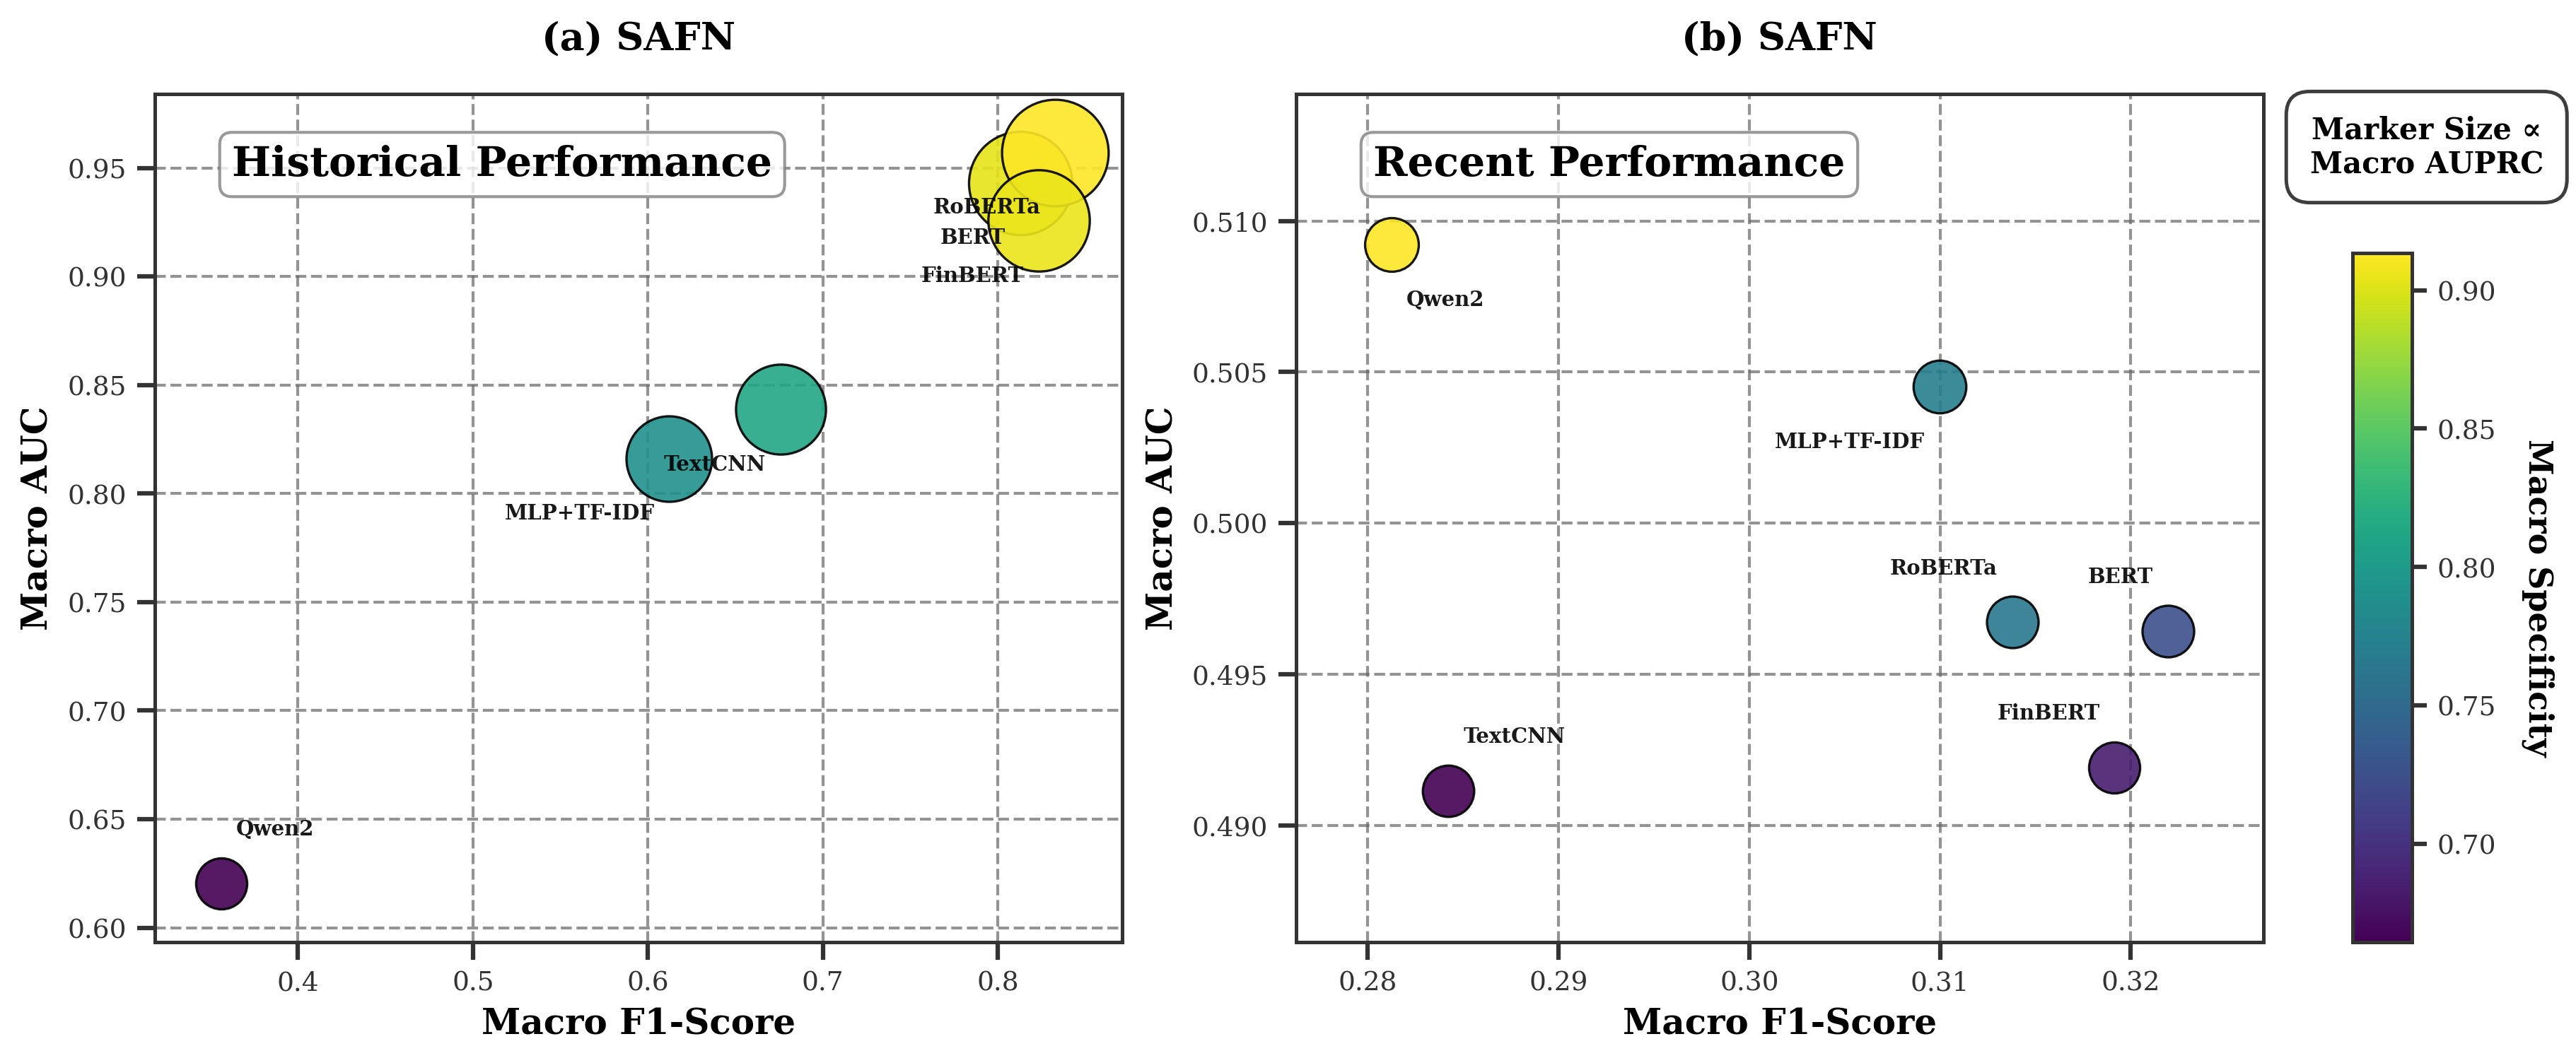

In [16]:
past_df = pd.read_csv("/kaggle/working/FNME_SAFN/modelPast_results.csv", index_col=0)
current_df = pd.read_csv("/kaggle/working/FNME_SAFN/model2025_results.csv", index_col=0)
plot_model_performance_comparison(past_df, current_df, "/kaggle/working/FNME_SAFN/comparison.png")

✓ Figure saved: /kaggle/working/FNME_SEntFiN/comparison.png/model_performance_comparison.png


(<Figure size 4200x1500 with 3 Axes>,
 array([<Axes: title={'center': '(a) SAFN'}, xlabel='Macro F1-Score', ylabel='Macro AUC'>,
        <Axes: title={'center': '(b) SAFN'}, xlabel='Macro F1-Score', ylabel='Macro AUC'>],
       dtype=object))

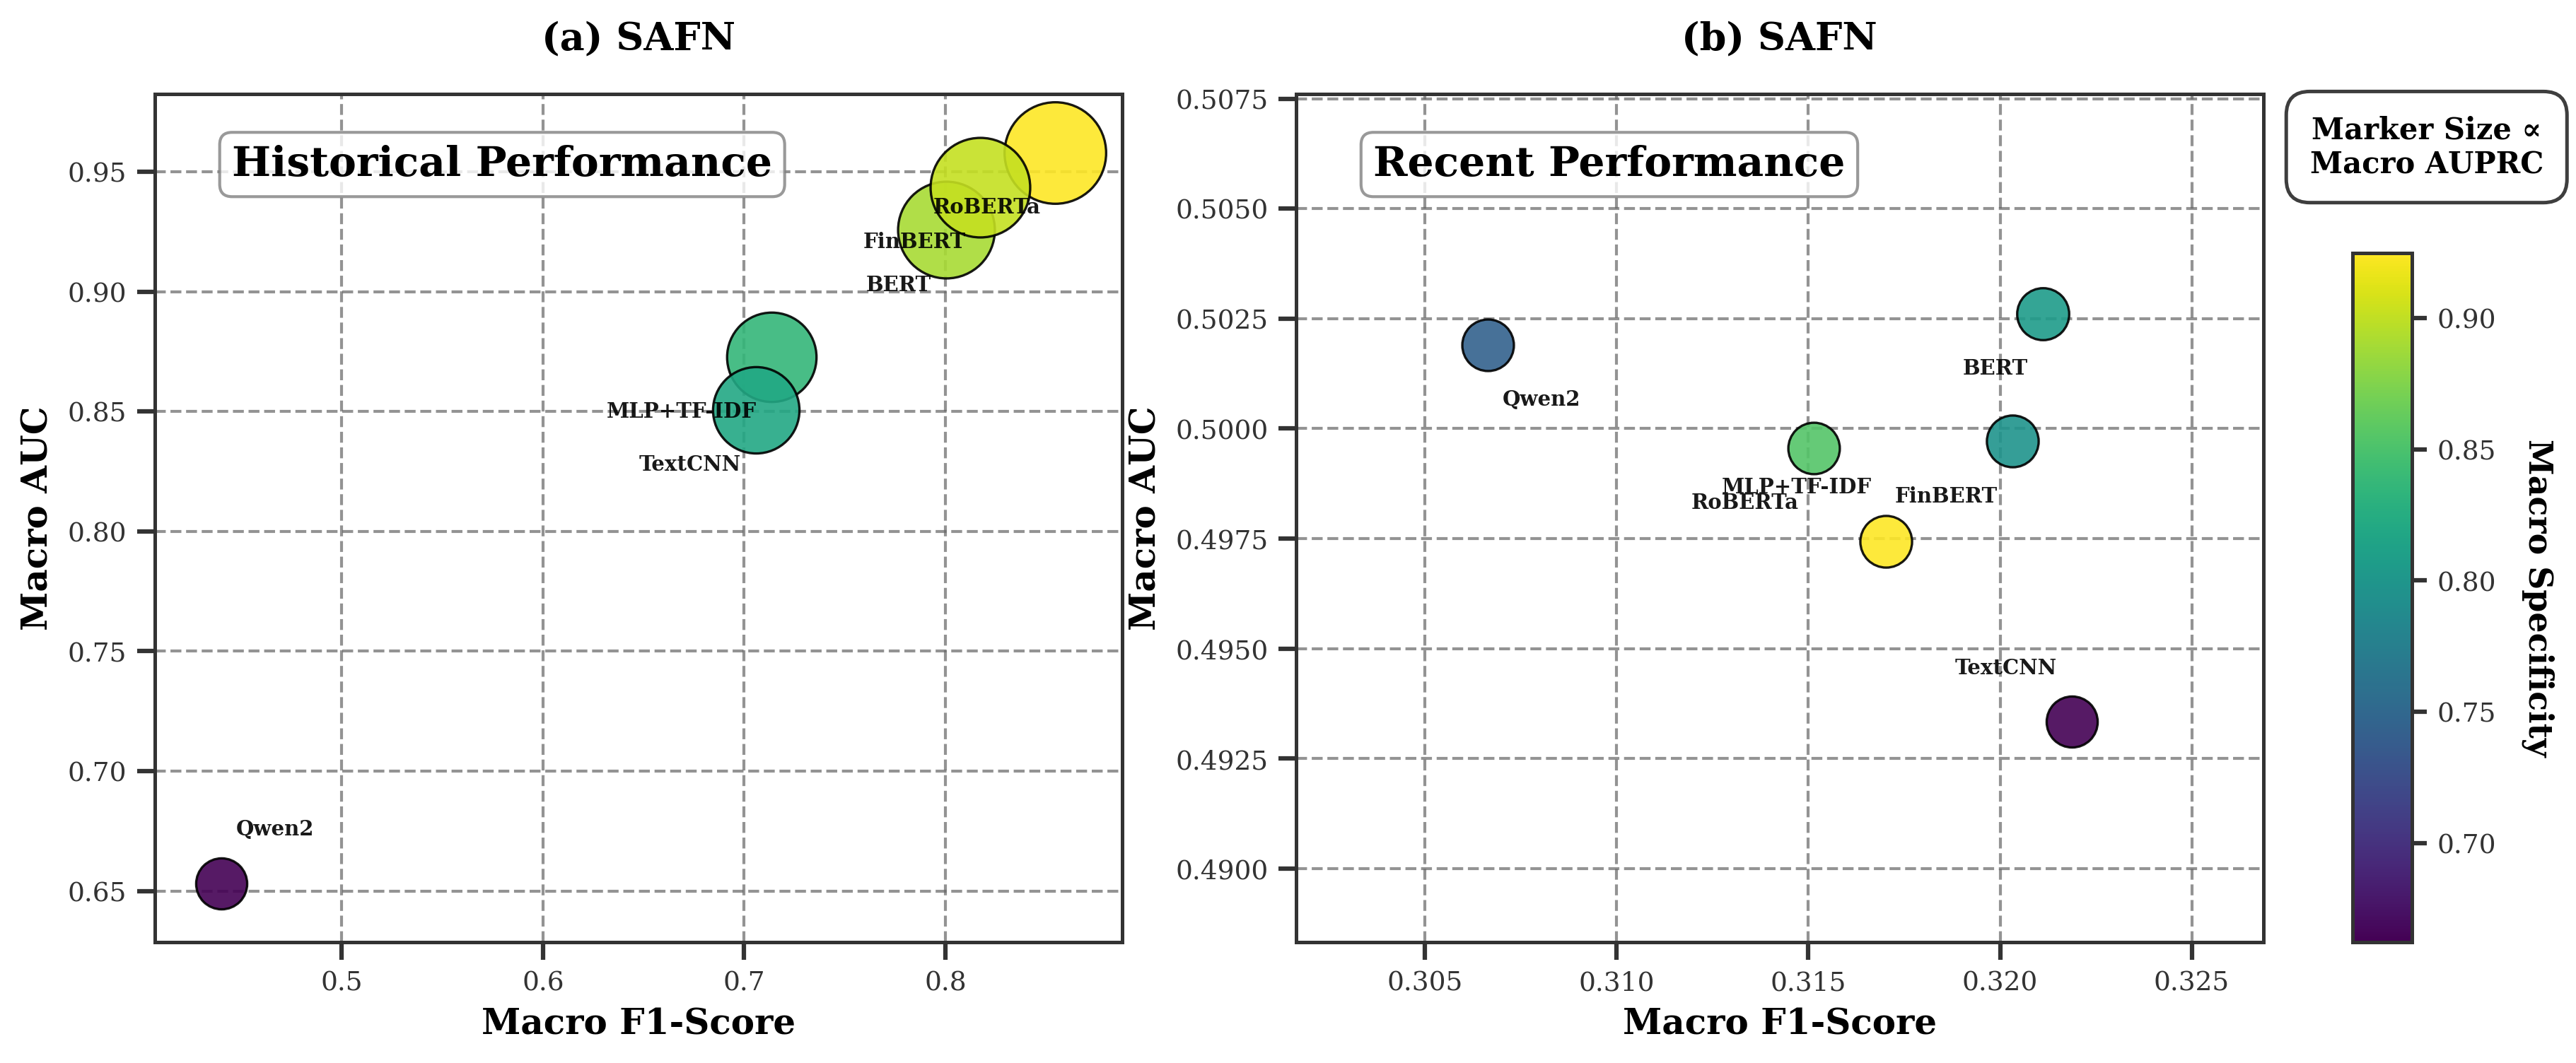

In [17]:
past_df = pd.read_csv("/kaggle/working/FNME_SEntFiN/modelPast_results.csv", index_col=0)
current_df = pd.read_csv("/kaggle/working/FNME_SEntFiN/model2025_results.csv", index_col=0)
plot_model_performance_comparison(past_df, current_df, "/kaggle/working/FNME_SEntFiN/comparison.png")

✓ Figure saved: /kaggle/working/four_dataset_comparison_horizontal.png


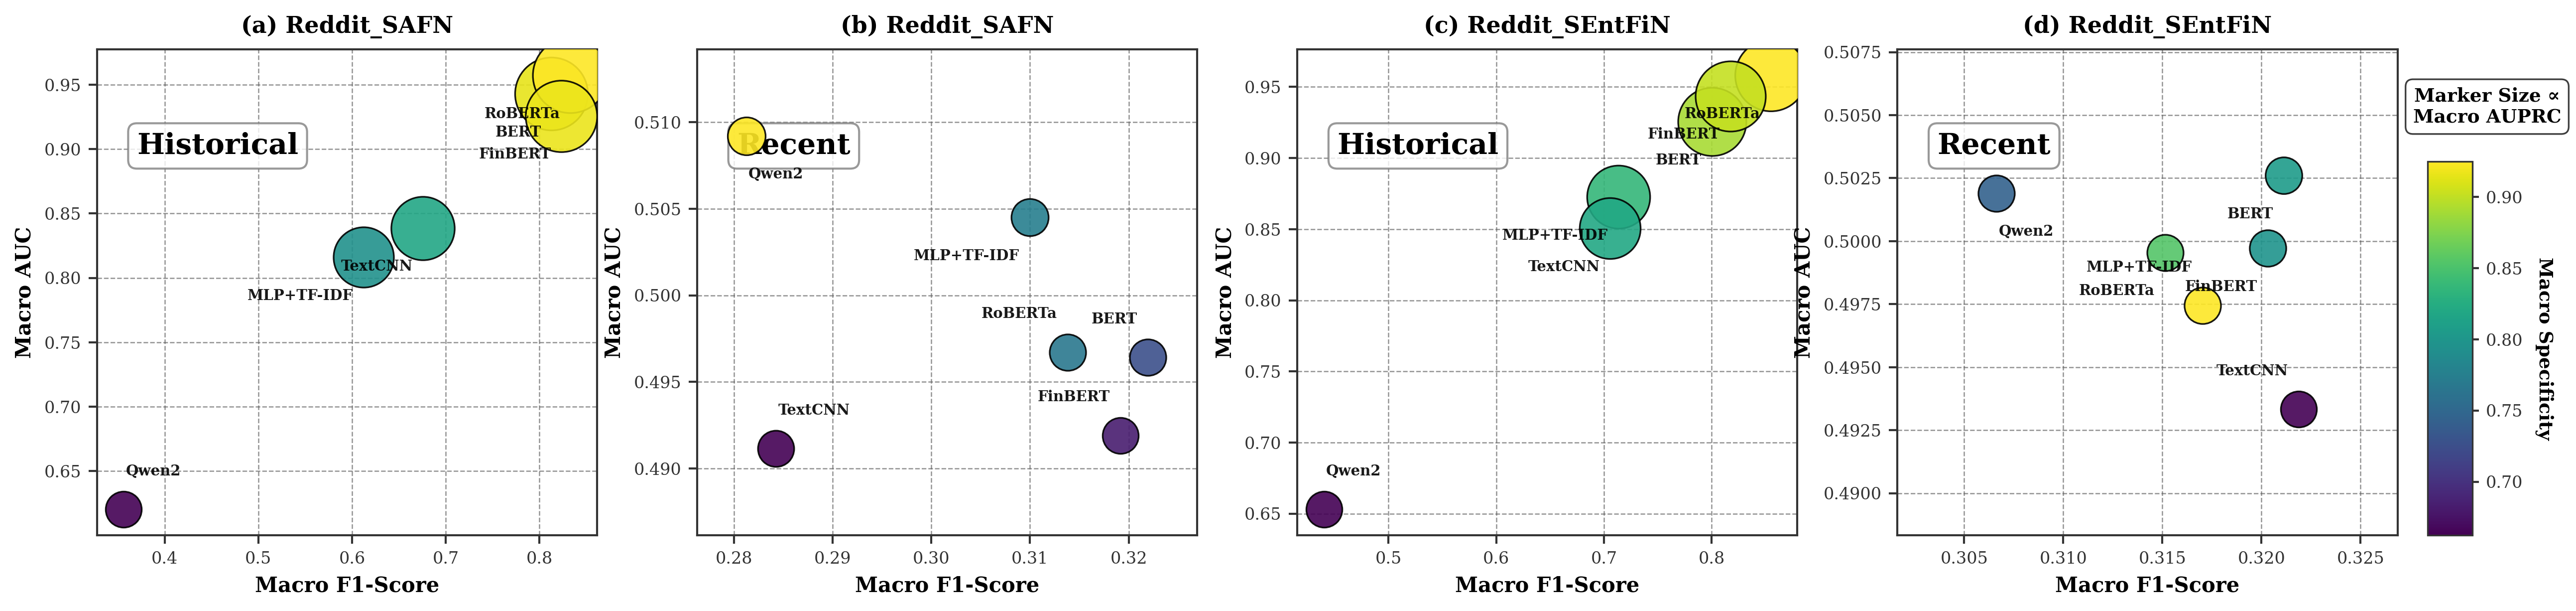

In [18]:
# def plot_four_dataset_comparison_horizontal(past_df_safn, current_df_safn, past_df_sentfin, current_df_sentfin, save_dir=None, figsize=(14, 5)):
    
#     plt.rcParams.update({
#         'font.family': 'serif',
#         'font.serif': ['Times New Roman', 'DejaVu Serif'],
#         'font.size': 9,
#         'axes.labelsize': 10,
#         'axes.titlesize': 11,
#         'legend.fontsize': 8,
#         'xtick.labelsize': 8,
#         'ytick.labelsize': 8,
#         'figure.dpi': 300,
#         'savefig.dpi': 300,
#         'axes.linewidth': 1.0,
#         'grid.linewidth': 0.8,
#         'grid.alpha': 0.6,
#         'axes.edgecolor': '#333333',
#         'xtick.color': '#333333',
#         'ytick.color': '#333333'
#     })

#     past_df_safn.columns = [str(col).strip() for col in past_df_safn.columns]
#     current_df_safn.columns = [str(col).strip() for col in current_df_safn.columns]
#     past_df_sentfin.columns = [str(col).strip() for col in past_df_sentfin.columns]
#     current_df_sentfin.columns = [str(col).strip() for col in current_df_sentfin.columns]

#     fig, axes = plt.subplots(1, 4, figsize=figsize, constrained_layout=False)

#     model_config = {
#         'mlp_tfidf': {'marker': 'o', 'name': 'MLP+TF-IDF'},
#         'textcnn': {'marker': 's', 'name': 'TextCNN'},
#         'bert': {'marker': '^', 'name': 'BERT'},
#         'roberta': {'marker': 'v', 'name': 'RoBERTa'},
#         'finbert': {'marker': 'D', 'name': 'FinBERT'}
#     }

#     def plot_subplot(ax, df, dataset_name, performance_type, subplot_label, dataset_type):

#         required_cols = ['Macro_F1', 'Macro_AUC', 'Macro_Specificity', 'Macro_AUPRC']
#         for col in required_cols:
#             if col not in df.columns:
#                 raise ValueError(f"Required column '{col}' not found in dataframe")

#         spec_min, spec_max = df['Macro_Specificity'].min(), df['Macro_Specificity'].max()
#         auprc_min, auprc_max = df['Macro_AUPRC'].min(), df['Macro_AUPRC'].max()

#         all_spec_vals = []
        
#         for model in df.index:
#             if model in model_config:
#                 config = model_config[model]
#                 x = df.loc[model, 'Macro_F1']
#                 y = df.loc[model, 'Macro_AUC']
#                 spec_val = df.loc[model, 'Macro_Specificity']
#                 auprc_val = df.loc[model, 'Macro_AUPRC']
#                 all_spec_vals.append(spec_val)

#                 norm_spec = (spec_val - spec_min) / (spec_max - spec_min) if spec_max > spec_min else 0.5
#                 color = plt.cm.viridis(norm_spec)

#                 size = 300 + (auprc_val - auprc_min) * 5000 if auprc_max > auprc_min else 500

#                 ax.scatter(x, y, s=size, c=[color], marker=config['marker'],
#                           alpha=0.9, edgecolors='black', linewidth=0.8,
#                           zorder=5)

#         ax.set_xlabel('Macro F1-Score', fontweight='bold', fontsize=10)
#         ax.set_ylabel('Macro AUC', fontweight='bold', fontsize=10)
#         title = f'({subplot_label}) {dataset_name}'
#         ax.set_title(title, fontweight='bold', pad=8, fontsize=11)

#         # Add performance type annotation in top-left corner
#         ax.text(0.08, 0.88, performance_type, transform=ax.transAxes,
#                fontsize=14, fontweight='bold', verticalalignment='top',
#                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='gray'))

#         ax.grid(True, alpha=0.7, linestyle='--', linewidth=0.6, color='#666666')

#         # Set different background colors for different datasets
#         if dataset_type == 'safn':
#             ax.set_facecolor('white')  # Light gray-blue for FNME_SAFN
#         else:  # sentfin
#             ax.set_facecolor('white')  # Light green-gray for SEntFiN

#         x_range = df['Macro_F1'].max() - df['Macro_F1'].min()
#         y_range = df['Macro_AUC'].max() - df['Macro_AUC'].min()
#         x_padding = max(x_range * 0.08, 0.005)
#         y_padding = max(y_range * 0.08, 0.005)
#         ax.set_xlim([df['Macro_F1'].min() - x_padding, df['Macro_F1'].max() + x_padding])
#         ax.set_ylim([df['Macro_AUC'].min() - y_padding, df['Macro_AUC'].max() + y_padding])

#         ax.tick_params(axis='both', which='major', width=1.0, length=4)
        
#         return all_spec_vals, spec_min, spec_max

#     all_spec_vals = []
#     spec_mins = []
#     spec_maxs = []
    
#     # FNME_SAFN Historical Performance
#     spec_vals1, spec_min1, spec_max1 = plot_subplot(
#         axes[0], past_df_safn, 'FNME_SAFN', 'Historical', 'a', 'safn'
#     )
#     all_spec_vals.extend(spec_vals1)
#     spec_mins.append(spec_min1)
#     spec_maxs.append(spec_max1)
    
#     # FNME_SAFN Recent Performance
#     spec_vals2, spec_min2, spec_max2 = plot_subplot(
#         axes[1], current_df_safn, 'FNME_SAFN', 'Recent', 'b', 'safn'
#     )
#     all_spec_vals.extend(spec_vals2)
#     spec_mins.append(spec_min2)
#     spec_maxs.append(spec_max2)
    
#     # SEntFiN Historical Performance
#     spec_vals3, spec_min3, spec_max3 = plot_subplot(
#         axes[2], past_df_sentfin, 'SEntFiN', 'Historical', 'c', 'sentfin'
#     )
#     all_spec_vals.extend(spec_vals3)
#     spec_mins.append(spec_min3)
#     spec_maxs.append(spec_max3)
    
#     # SEntFiN Recent Performance
#     spec_vals4, spec_min4, spec_max4 = plot_subplot(
#         axes[3], current_df_sentfin, 'SEntFiN', 'Recent', 'd', 'sentfin'
#     )
#     all_spec_vals.extend(spec_vals4)
#     spec_mins.append(spec_min4)
#     spec_maxs.append(spec_max4)

#     plt.subplots_adjust(left=0.05, right=0.82, wspace=0.25, bottom=0.15, top=0.85)

#     shape_legend = [
#         Line2D([0], [0], marker=config['marker'], color='gray',
#                label=config['name'], markersize=10, linestyle='None',
#                markeredgecolor='black', markeredgewidth=0.8)
#         for config in model_config.values()
#     ]
    
#     # Marker Size
#     size_legend = fig.text(0.86, 0.80, 'Marker Size ∝\nMacro AUPRC', 
#                           ha='center', va='top', fontsize=9, fontweight='bold',
#                           bbox=dict(boxstyle="round,pad=0.4", facecolor='white', alpha=0.95, 
#                                    edgecolor='#333333', linewidth=0.8))
    
#     # Models
#     models_leg = fig.legend(handles=shape_legend, loc='upper right',
#                            title='Models', title_fontsize=10, 
#                            frameon=True, fancybox=True, shadow=True, labelspacing=0.6,
#                            borderpad=0.4, handletextpad=0.6, columnspacing=0.8,
#                            fontsize=8, bbox_to_anchor=(0.89, 0.7))
#     models_leg.get_frame().set_facecolor('white')
#     models_leg.get_frame().set_edgecolor('#333333')
#     models_leg.get_frame().set_linewidth(0.8)
#     models_leg.get_frame().set_alpha(0.95)
    
#     # Specificity
#     all_spec_min = min(spec_mins)
#     all_spec_max = max(spec_maxs)
#     norm = mpl.colors.Normalize(vmin=all_spec_min, vmax=all_spec_max)
#     sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=norm)
#     sm.set_array([])

#     cbar_ax = fig.add_axes([0.84, 0.12, 0.015, 0.3])
#     cbar = plt.colorbar(sm, cax=cbar_ax, orientation='vertical')
#     cbar.set_label('Macro Specificity', fontweight='bold', fontsize=9, 
#                   rotation=270, labelpad=15)
#     cbar.ax.tick_params(labelsize=8)
#     cbar.outline.set_linewidth(0.8)
#     cbar.outline.set_edgecolor('#333333')
#     cbar.ax.yaxis.set_tick_params(width=1.0, length=3)
    
#     if save_dir:
#         os.makedirs(save_dir, exist_ok=True)
#         save_path = os.path.join(save_dir, 'four_dataset_comparison_horizontal.png')
#         plt.savefig(save_path, dpi=300, bbox_inches='tight')
#         print(f"✓ Figure saved: {save_path}")
    
#     return fig, axes


def plot_four_dataset_comparison_horizontal(past_df_safn, current_df_safn, past_df_sentfin, current_df_sentfin, save_dir=None, figsize=(20, 5)):
    
    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'],
        'font.size': 9,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'legend.fontsize': 8,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'axes.linewidth': 1.0,
        'grid.linewidth': 0.8,
        'grid.alpha': 0.6,
        'axes.edgecolor': '#333333',
        'xtick.color': '#333333',
        'ytick.color': '#333333'
    })

    # Clean column names
    past_df_safn.columns = [str(col).strip() for col in past_df_safn.columns]
    current_df_safn.columns = [str(col).strip() for col in current_df_safn.columns]
    past_df_sentfin.columns = [str(col).strip() for col in past_df_sentfin.columns]
    current_df_sentfin.columns = [str(col).strip() for col in current_df_sentfin.columns]

    fig, axes = plt.subplots(1, 4, figsize=figsize, constrained_layout=False)

    # Model names mapping (all use circle marker)
    model_names = {
        'mlp_tfidf': 'MLP+TF-IDF',
        'textcnn': 'TextCNN',
        'bert': 'BERT',
        'roberta': 'RoBERTa',
        'finbert': 'FinBERT',
        'qwen2': 'Qwen2'
    }

    def plot_subplot(ax, df, dataset_name, performance_type, subplot_label, dataset_type):

        required_cols = ['Macro_F1', 'Macro_AUC', 'Macro_Specificity', 'Macro_AUPRC']
        for col in required_cols:
            if col not in df.columns:
                raise ValueError(f"Required column '{col}' not found in dataframe")

        spec_min, spec_max = df['Macro_Specificity'].min(), df['Macro_Specificity'].max()
        auprc_min, auprc_max = df['Macro_AUPRC'].min(), df['Macro_AUPRC'].max()

        all_spec_vals = []

        for model in df.index:
            if model in model_names:
                x = df.loc[model, 'Macro_F1']
                y = df.loc[model, 'Macro_AUC']
                spec_val = df.loc[model, 'Macro_Specificity']
                auprc_val = df.loc[model, 'Macro_AUPRC']
                all_spec_vals.append(spec_val)
        
                # Normalize specificity for color mapping
                norm_spec = (spec_val - spec_min) / (spec_max - spec_min) if spec_max > spec_min else 0.5
                color = plt.cm.viridis(norm_spec)
                # color = plt.cm.Purples(norm_spec)
                
        
                # Calculate marker size based on AUPRC
                size = 300 + (auprc_val - auprc_min) * 2000 if auprc_max > auprc_min else 500
        
                # Plot marker (always circle)
                ax.scatter(x, y, s=size, c=[color], marker='o',
                          alpha=0.9, edgecolors='black', linewidth=0.8,
                          zorder=5)
                
                # Add model name as text label
                model_name = model_names.get(model, model)
                
                # Calculate data center
                x_center = (df['Macro_F1'].min() + df['Macro_F1'].max()) / 2
                y_center = (df['Macro_AUC'].min() + df['Macro_AUC'].max()) / 2
                
                # Determine offset direction
                if x > x_center:
                    x_offset = -5
                else:
                    x_offset = 1
                    
                if y > y_center:
                    y_offset = -15
                else:
                    y_offset = 15

                if x_offset > 0:
                    ha =  'left'
                else:
                    ha = 'right'
                    
                if y_offset > 0:
                    va = 'bottom'
                else:
                    va = 'top'
                
                # Add model name as annotation
                ax.annotate(model_name, 
                           xy=(x, y),
                           xytext=(x_offset, y_offset),  # Directional offset
                           textcoords='offset points',
                           fontsize=7,
                           fontweight='bold',
                           color='black',
                           alpha=0.9,
                           bbox=dict(boxstyle="round,pad=0.2", 
                                    facecolor='white', 
                                    alpha=0, 
                                    edgecolor='none',
                                    linewidth=0.5),
                           zorder=6,
                           #va='bottom',
                           #ha='right',
                           ha=ha,
                           va=va)
        
        ax.set_xlabel('Macro F1-Score', fontweight='bold', fontsize=10)
        ax.set_ylabel('Macro AUC', fontweight='bold', fontsize=10)
        title = f'({subplot_label}) {dataset_name}'
        ax.set_title(title, fontweight='bold', pad=8, fontsize=11)

        # Add performance type annotation
        ax.text(0.08, 0.83, performance_type, transform=ax.transAxes,
               fontsize=14, fontweight='bold', verticalalignment='top',
               bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='gray'))

        ax.grid(True, alpha=0.7, linestyle='--', linewidth=0.6, color='#666666')

        # Set background colors
        if dataset_type == 'safn':
            ax.set_facecolor('white')
        else:  # sentfin
            ax.set_facecolor('white')

        # Set axis limits with padding
        x_range = df['Macro_F1'].max() - df['Macro_F1'].min()
        y_range = df['Macro_AUC'].max() - df['Macro_AUC'].min()
        x_padding = max(x_range * 0.06, 0.005)
        y_padding = max(y_range * 0.06, 0.005)
        ax.set_xlim([df['Macro_F1'].min() - x_padding, df['Macro_F1'].max() + x_padding])
        ax.set_ylim([df['Macro_AUC'].min() - y_padding, df['Macro_AUC'].max() + y_padding])

        ax.tick_params(axis='both', which='major', width=1.0, length=4)
        
        return all_spec_vals, spec_min, spec_max

    all_spec_vals = []
    spec_mins = []
    spec_maxs = []
    
    # Plot all 4 subplots
    spec_vals1, spec_min1, spec_max1 = plot_subplot(
        axes[0], past_df_safn, 'Reddit_SAFN', 'Historical', 'a', 'safn'
    )
    all_spec_vals.extend(spec_vals1)
    spec_mins.append(spec_min1)
    spec_maxs.append(spec_max1)
    
    spec_vals2, spec_min2, spec_max2 = plot_subplot(
        axes[1], current_df_safn, 'Reddit_SAFN', 'Recent', 'b', 'safn'
    )
    all_spec_vals.extend(spec_vals2)
    spec_mins.append(spec_min2)
    spec_maxs.append(spec_max2)
    
    spec_vals3, spec_min3, spec_max3 = plot_subplot(
        axes[2], past_df_sentfin, 'Reddit_SEntFiN', 'Historical', 'c', 'sentfin'
    )
    all_spec_vals.extend(spec_vals3)
    spec_mins.append(spec_min3)
    spec_maxs.append(spec_max3)
    
    spec_vals4, spec_min4, spec_max4 = plot_subplot(
        axes[3], current_df_sentfin, 'Reddit_SEntFiN', 'Recent', 'd', 'sentfin'
    )
    all_spec_vals.extend(spec_vals4)
    spec_mins.append(spec_min4)
    spec_maxs.append(spec_max4)

    plt.subplots_adjust(left=0.05, right=0.82, wspace=0.2, bottom=0.2, top=0.85)

    # Create a simple legend showing the colorbar meaning
    # Marker Size legend
    size_legend = fig.text(0.85, 0.80, 'Marker Size ∝\nMacro AUPRC', 
                          ha='center', va='top', fontsize=9, fontweight='bold',
                          bbox=dict(boxstyle="round,pad=0.4", facecolor='white', alpha=0.95, 
                                   edgecolor='#333333', linewidth=0.8))
    
    # Colorbar for Specificity
    all_spec_min = min(spec_mins)
    all_spec_max = max(spec_maxs)
    norm = mpl.colors.Normalize(vmin=all_spec_min, vmax=all_spec_max)
    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=norm)
    # sm = plt.cm.ScalarMappable(cmap=plt.cm.Purples, norm=norm)
    sm.set_array([])

    cbar_ax = fig.add_axes([0.83, 0.2, 0.015, 0.5])
    cbar = plt.colorbar(sm, cax=cbar_ax, orientation='vertical')
    cbar.set_label('Macro Specificity', fontweight='bold', fontsize=9, 
                  rotation=270, labelpad=15)
    cbar.ax.tick_params(labelsize=8)
    cbar.outline.set_linewidth(0.8)
    cbar.outline.set_edgecolor('#333333')
    cbar.ax.yaxis.set_tick_params(width=1.0, length=3)
    
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, 'four_dataset_comparison_horizontal.png')
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Figure saved: {save_path}")
    
    return fig, axes


past_df_safn = pd.read_csv("/kaggle/working/FNME_SAFN/modelPast_results.csv", index_col=0)
current_df_safn = pd.read_csv("/kaggle/working/FNME_SAFN/model2025_results.csv", index_col=0)
past_df_sentfin = pd.read_csv("/kaggle/working/FNME_SEntFiN/modelPast_results.csv", index_col=0)
current_df_sentfin = pd.read_csv("/kaggle/working/FNME_SEntFiN/model2025_results.csv", index_col=0)

fig, axes = plot_four_dataset_comparison_horizontal(
    past_df_safn=past_df_safn,
    current_df_safn=current_df_safn,
    past_df_sentfin=past_df_sentfin,
    current_df_sentfin=current_df_sentfin,
    save_dir="/kaggle/working",
    figsize=(20, 5)  
)

plt.show()

# Models Contrast
## ROC

In [19]:
def plot_all_models_roc_curves(all_models_roc_data, save_path='all_models_roc_curves.png'):

    plt.rcParams.update({
        'font.size': 10,
        'axes.titlesize': 11,
        'axes.labelsize': 10,
        'legend.fontsize': 8,
        'figure.titlesize': 12
    })
    
    models = all_models_roc_data['model'].unique()
    classes = all_models_roc_data['class_name'].unique()

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    
    fig.patch.set_facecolor('white')
    for ax in axes:
        ax.set_facecolor('#f3f2f9')
        ax.set_axisbelow(True)
        ax.grid(True, alpha=0.7, color='#b0b0b0', linestyle='--', linewidth=0.5)
    # for ax in axes:
    #     ax.set_facecolor('#ffffff')
    #     ax.set_axisbelow(True)
    #     ax.grid(True, alpha=0.3, color='#b0b0b0', linestyle='-', linewidth=0.5)
    #     ax.axhspan(0.8, 1.0, alpha=0.1, color='green')
    #     ax.axhspan(0.6, 0.8, alpha=0.1, color='orange')
    #     ax.axhspan(0.0, 0.6, alpha=0.1, color='red')


    model_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

    for class_idx, (class_name, ax) in enumerate(zip(classes, axes)):
        ax.set_title(f'{class_name.capitalize()}', fontsize=11, fontweight='bold')
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])

        ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5) # label='Random'

        for model_idx, model in enumerate(models):
            class_data = all_models_roc_data[
                (all_models_roc_data['model'] == model) & 
                (all_models_roc_data['class_name'] == class_name)
            ]
            
            if len(class_data) > 0:
                auc_value = class_data['auc'].iloc[0]
                color = model_colors[model_idx % len(model_colors)]
                ax.plot(class_data['fpr'], class_data['tpr'],
                       color=color,
                       linewidth=2,
                       label=f'{model} ({auc_value:.3f})')

        ax.legend(loc='lower right')

    # plt.suptitle('ROC Curves by Class', fontsize=12, fontweight='bold')

    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    return save_path

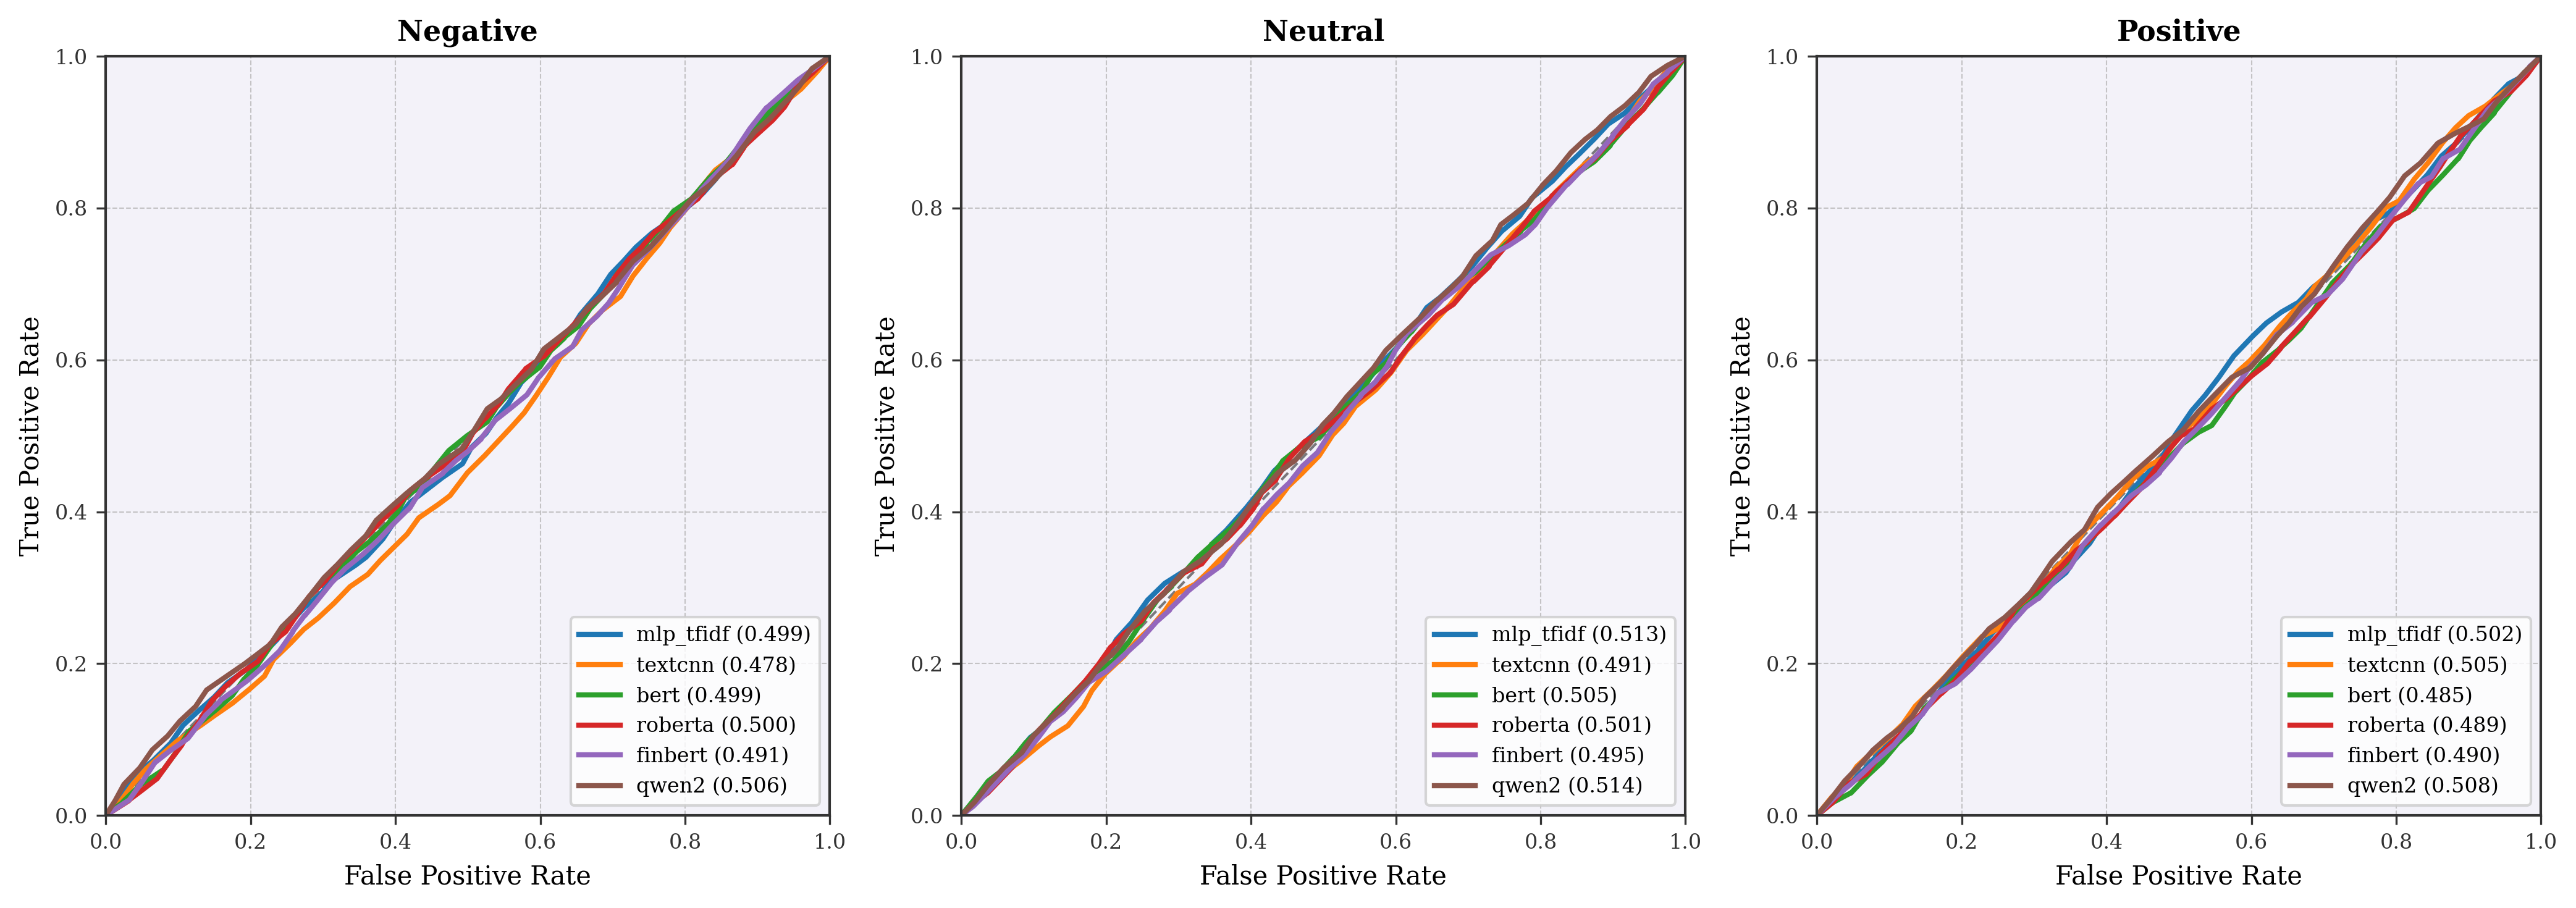

'SAFN2025_roc_curves.png'

In [20]:
SAFN2025_res = pd.read_csv('/kaggle/working/FNME_SAFN/all2025_models_roc_data.csv')
plot_all_models_roc_curves(SAFN2025_res, 'SAFN2025_roc_curves.png')

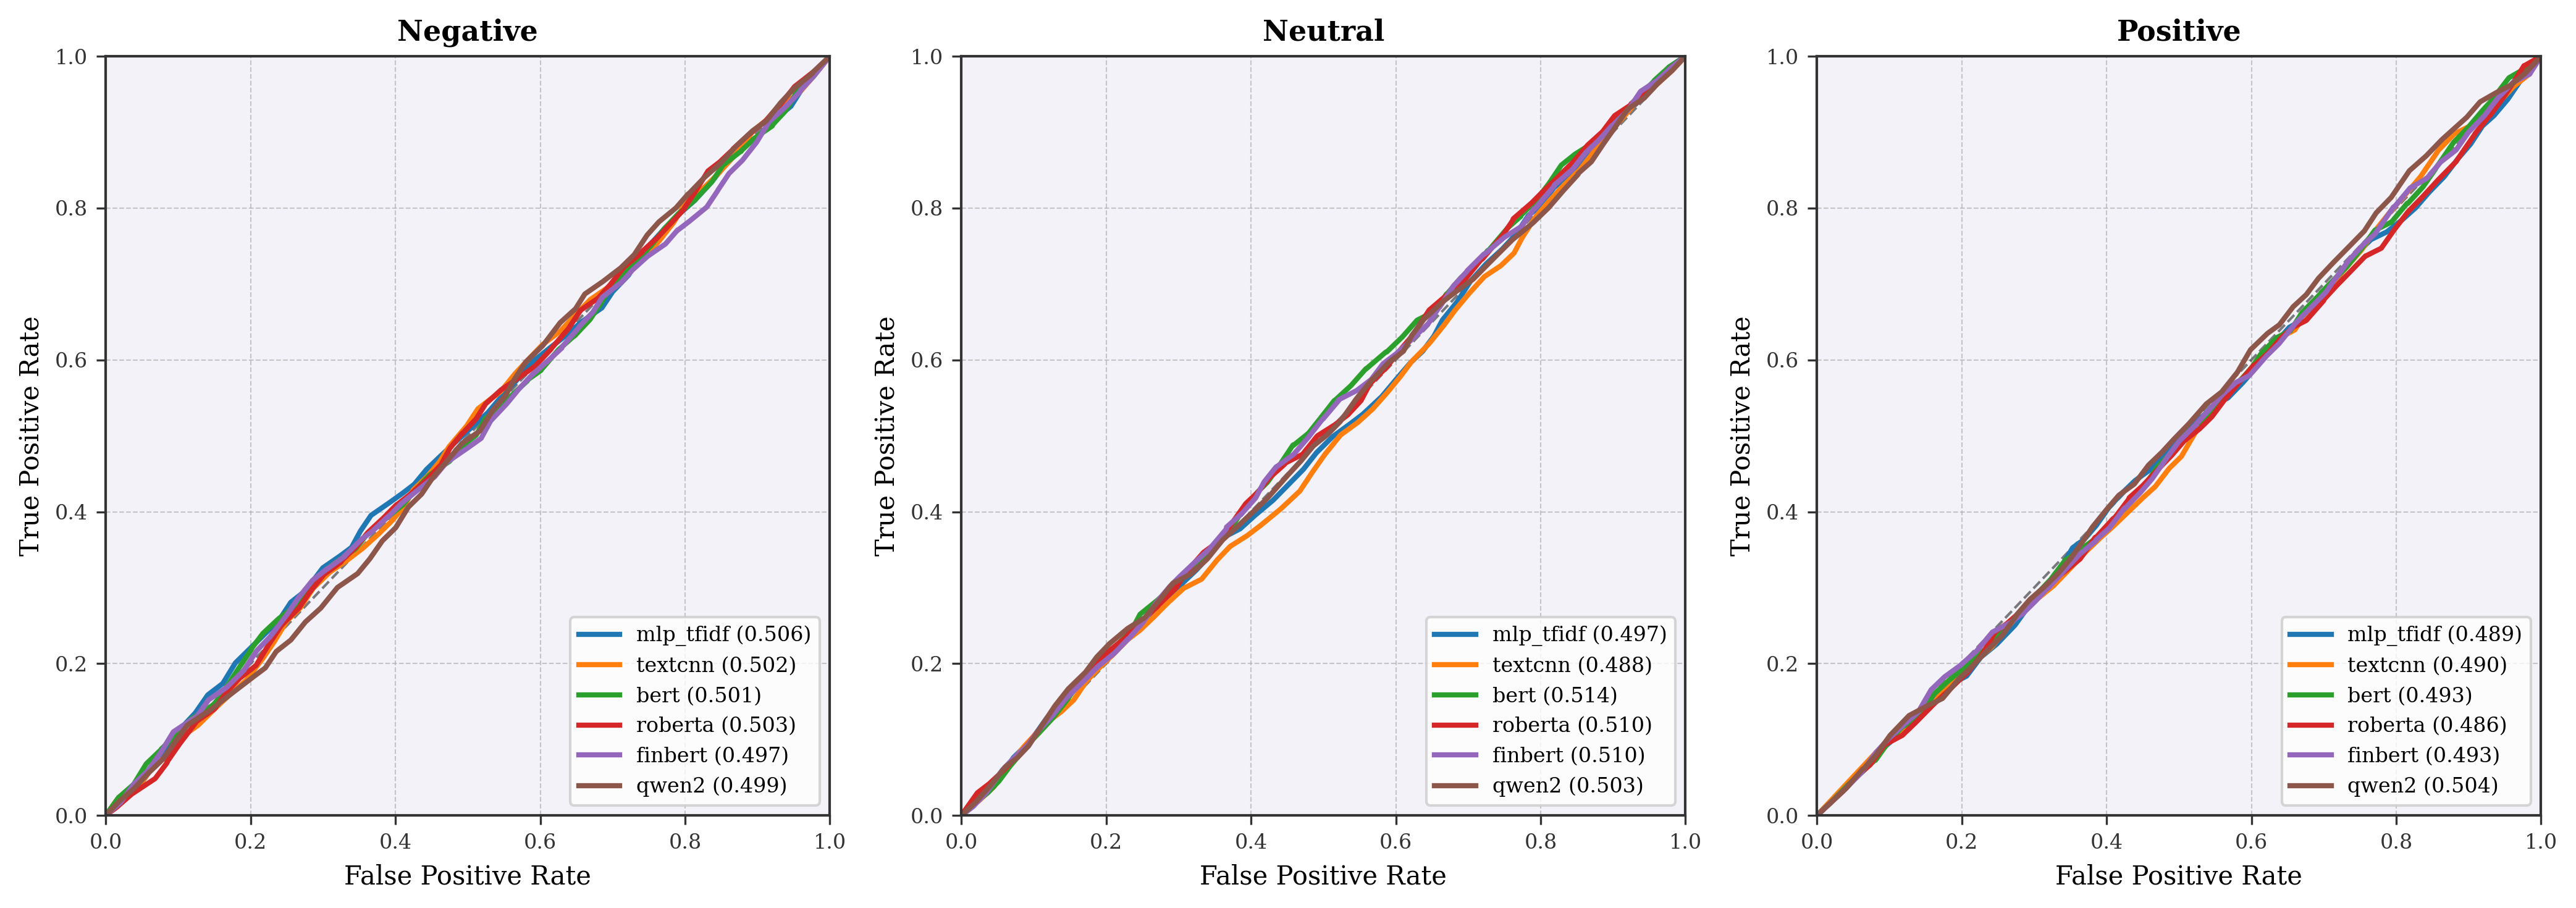

'SEntFiN2025_roc_curves.png'

In [21]:
SEntFiN2025_res = pd.read_csv('/kaggle/working/FNME_SEntFiN/all2025_models_roc_data.csv')
plot_all_models_roc_curves(SEntFiN2025_res, 'SEntFiN2025_roc_curves.png')

## Change Rate Bar chart

✓ Figure saved: /kaggle/working/performance_decline_barcharts.png


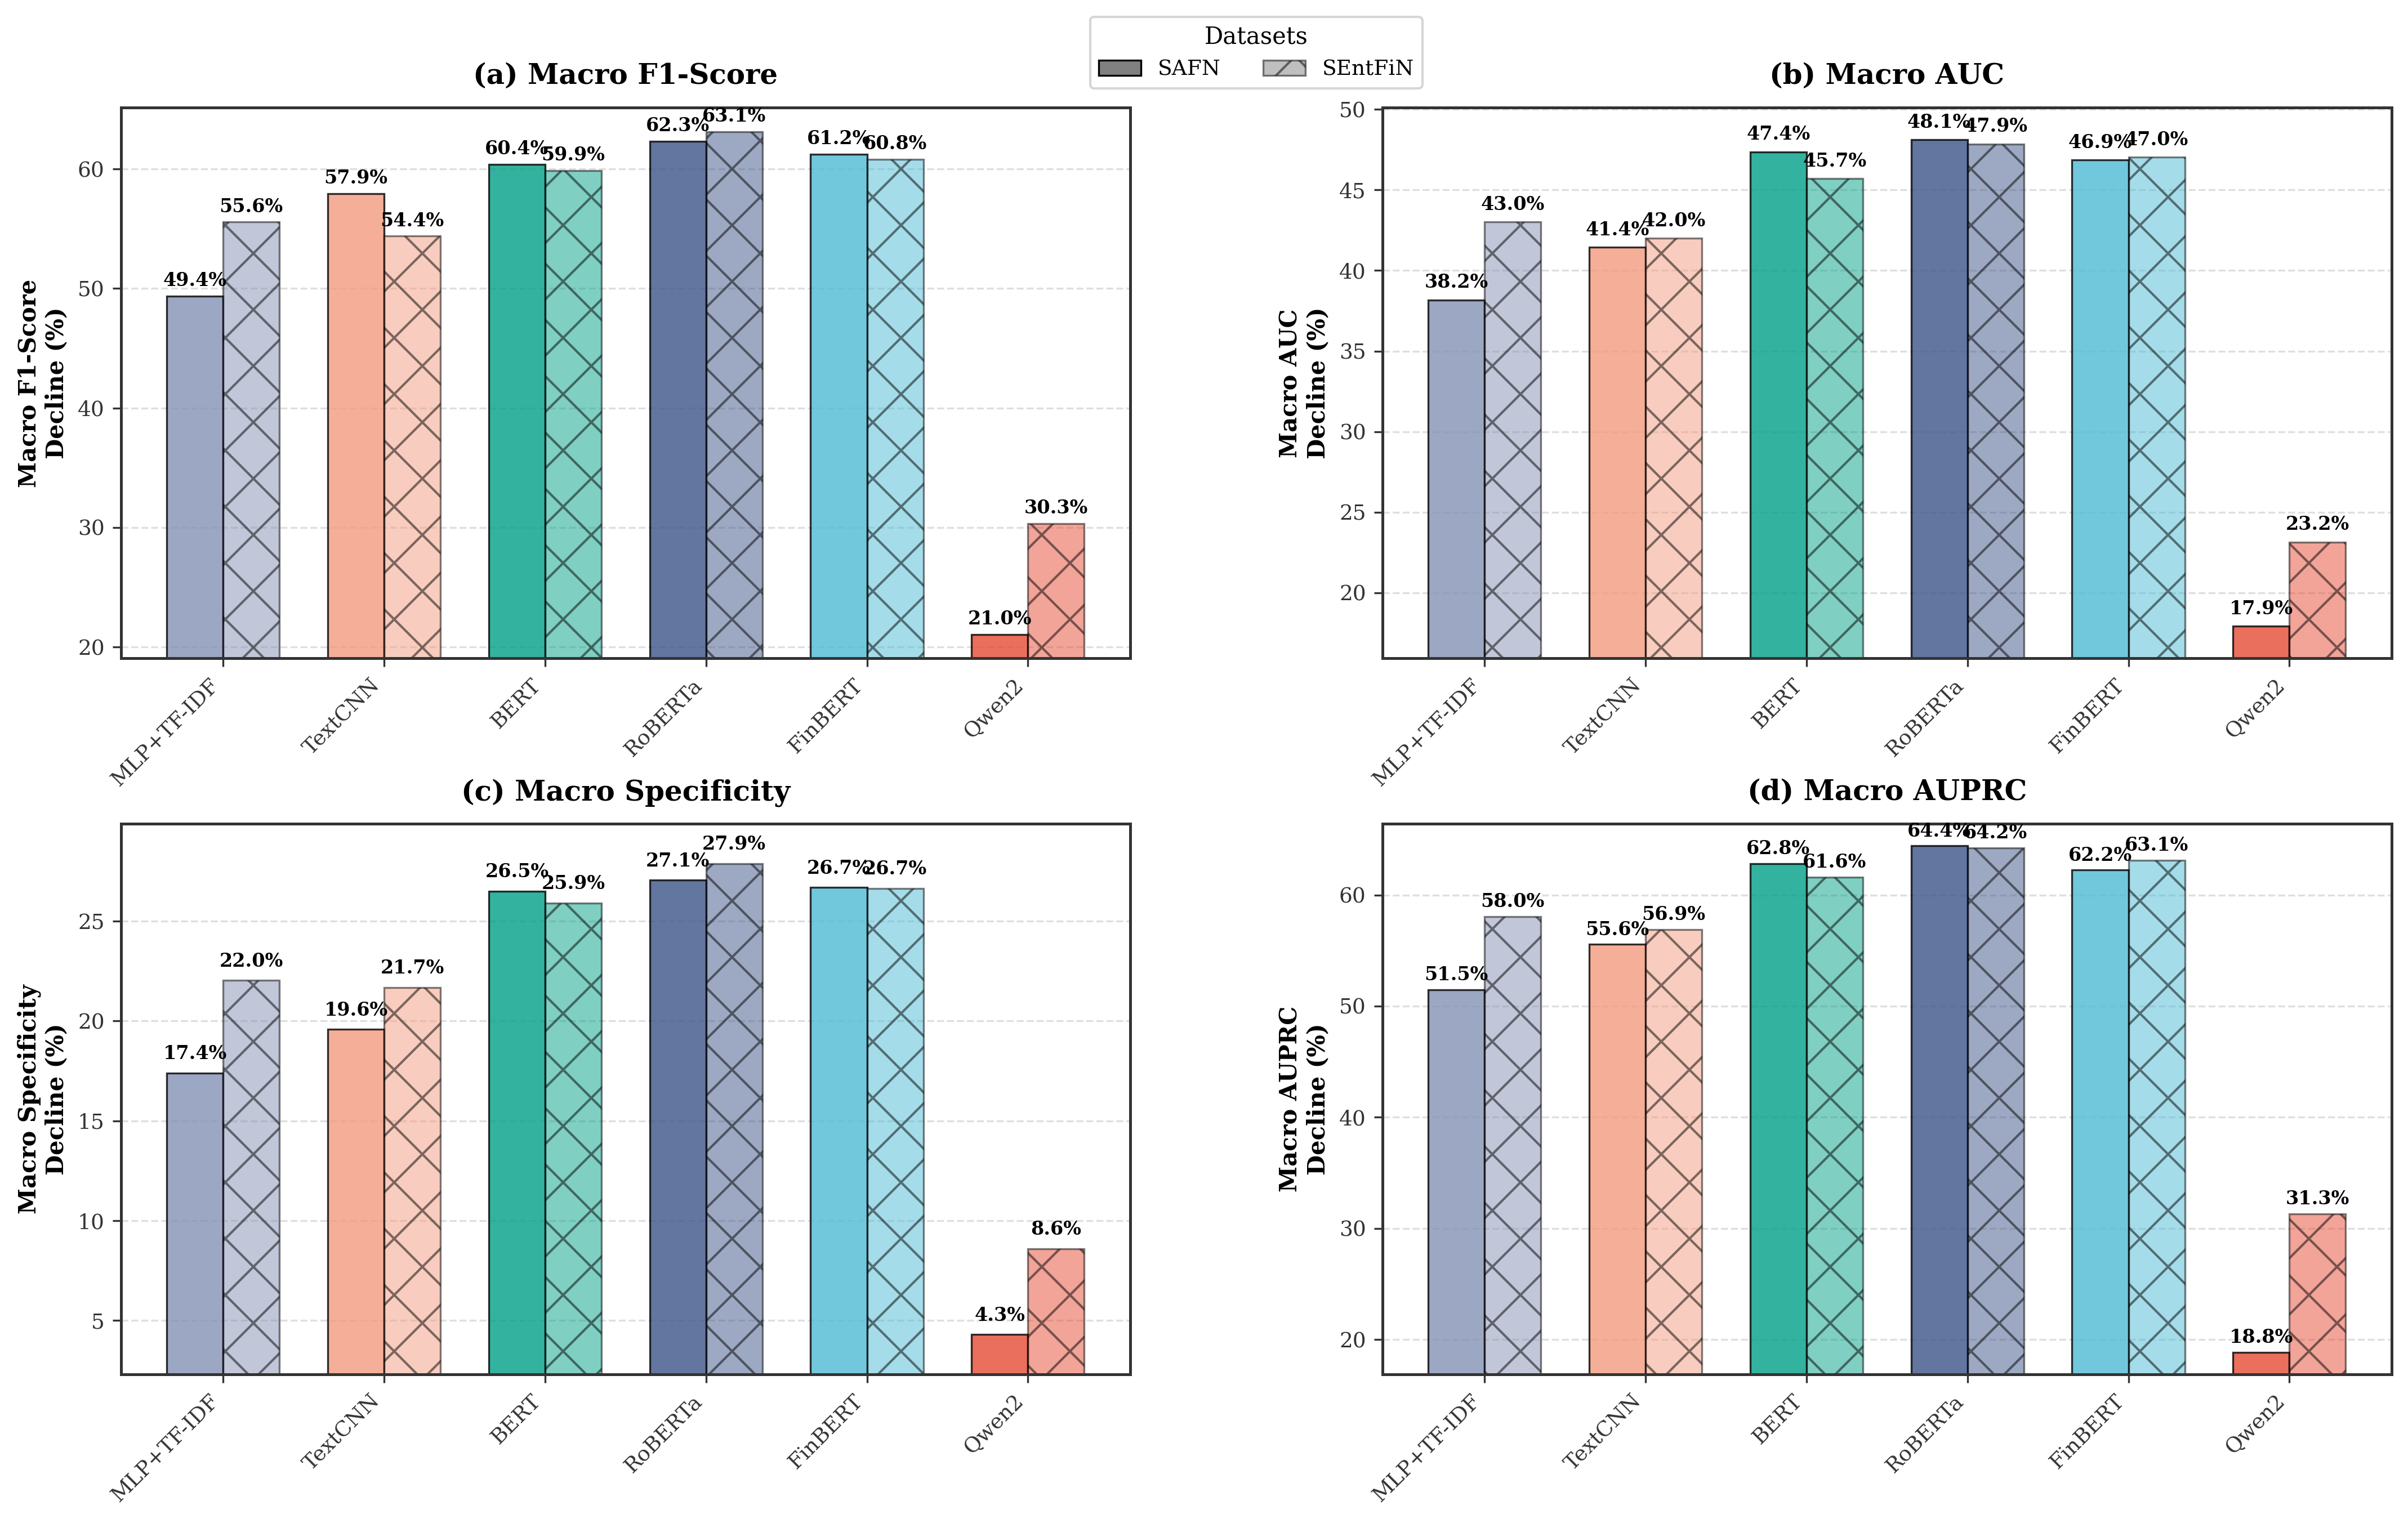

In [22]:
def plot_performance_decline_barcharts_v2(past_df_safn, current_df_safn, past_df_sentfin, current_df_sentfin, save_dir=None, figsize=(14, 10)):
    
    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'],
        'font.size': 10,
        'axes.labelsize': 11,
        'axes.titlesize': 12,
        'legend.fontsize': 9,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'axes.linewidth': 1.2,
        'grid.linewidth': 0.8,
        'grid.alpha': 0.6,
        'axes.edgecolor': '#333333',
        'xtick.color': '#333333',
        'ytick.color': '#333333'
    })
    
    past_df_safn.columns = [str(col).strip() for col in past_df_safn.columns]
    current_df_safn.columns = [str(col).strip() for col in current_df_safn.columns]
    past_df_sentfin.columns = [str(col).strip() for col in past_df_sentfin.columns]
    current_df_sentfin.columns = [str(col).strip() for col in current_df_sentfin.columns]
    
    metrics = ['Macro_F1', 'Macro_AUC', 'Macro_Specificity', 'Macro_AUPRC']
    metric_names = {
        'Macro_F1': 'Macro F1-Score',
        'Macro_AUC': 'Macro AUC',
        'Macro_Specificity': 'Macro Specificity',
        'Macro_AUPRC': 'Macro AUPRC'
    }
    
    models = ['mlp_tfidf', 'textcnn', 'bert', 'roberta', 'finbert', 'qwen2']
    model_names = {
        'mlp_tfidf': 'MLP+TF-IDF',
        'textcnn': 'TextCNN',
        'bert': 'BERT',
        'roberta': 'RoBERTa',
        'finbert': 'FinBERT',
        'qwen2': 'Qwen2'
    }
    
    model_colors = ['#8491B4', '#F39B7F', '#00A087', '#3C5488', '#4DBBD5', '#E64B35']
    
    def calculate_decline_percentage(past_df, current_df, metric):
        decline_data = {}
        for model in models:
            if model in past_df.index and model in current_df.index:
                past_value = past_df.loc[model, metric]
                current_value = current_df.loc[model, metric]
                if past_value != 0:
                    decline_percent = ((past_value - current_value) / past_value) * 100
                else:
                    decline_percent = 0
                decline_data[model] = decline_percent
        return decline_data
    
    decline_data = {}
    for metric in metrics:
        decline_data[metric] = {
            'SAFN': calculate_decline_percentage(past_df_safn, current_df_safn, metric),
            'SEntFiN': calculate_decline_percentage(past_df_sentfin, current_df_sentfin, metric)
        }
    
    fig, axes = plt.subplots(2, 2, figsize=figsize, constrained_layout=False)
    axes = axes.flatten()
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        
        safn_data = decline_data[metric]['SAFN']
        sentfin_data = decline_data[metric]['SEntFiN']
        
        model_labels = [model_names[model] for model in models if model in safn_data]
        safn_values = [safn_data[model] for model in models if model in safn_data]
        sentfin_values = [sentfin_data[model] for model in models if model in sentfin_data]
        
        x = np.arange(len(model_labels))
        width = 0.35
        
        for i, model in enumerate(models):
            if model in safn_data and model in sentfin_data:
                base_color = model_colors[i]
                
                safn_color = base_color
                sentfin_color = base_color
                
                bar_safn = ax.bar(x[i] - width/2, safn_data[model], width,
                                 color=safn_color, edgecolor='black', linewidth=0.8, alpha=0.8,
                                 hatch='', label='SAFN' if i == 0 else "")
                
                bar_sentfin = ax.bar(x[i] + width/2, sentfin_data[model], width,
                                    color=sentfin_color, edgecolor='black', linewidth=0.8, alpha=0.5,
                                    hatch='x', label='SEntFiN' if i == 0 else "")
                
                def add_value_label(bar, dataset):
                    height = bar[0].get_height()
                    if height != 0:
                        label = f'{height:.1f}%'
                        if height >= 0:
                            va = 'bottom'
                            y_offset = 0.5
                        else:
                            va = 'top'
                            y_offset = -0.5
                        ax.text(bar[0].get_x() + bar[0].get_width()/2., height + y_offset,
                               label, ha='center', va=va, fontsize=8, fontweight='bold')
                
                add_value_label(bar_safn, 'SAFN')
                add_value_label(bar_sentfin, 'SEntFiN')
        
        #ax.set_xlabel('Models', fontweight='bold', fontsize=10)
        ax.set_ylabel(f'{metric_names[metric]}\nDecline (%)', fontweight='bold', fontsize=10)
        ax.set_title(f'({["a","b","c","d"][idx]}) {metric_names[metric]}', fontweight='bold', pad=10, fontsize=12)
        ax.set_xticks(x)
        ax.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=9)
        ax.grid(True, axis='y', alpha=0.4, linestyle='--')
        ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
        ax.set_axisbelow(True)
        
        all_values = safn_values + sentfin_values
        if all_values:
            y_min = min(all_values) - 2
            y_max = max(all_values) + 2
            ax.set_ylim([y_min, y_max])
    
    plt.subplots_adjust(left=0.08, right=0.92, bottom=0.15, top=0.9, hspace=0.3, wspace=0.25)
    
    from matplotlib.patches import Patch
    
    dataset_legend_elements = [
        Patch(facecolor='gray', edgecolor='black', linewidth=0.8, hatch='', label='SAFN'),
        Patch(facecolor='gray', edgecolor='black', linewidth=0.8, hatch='x', label='SEntFiN', alpha=0.5)
    ]
    
    fig.legend(handles=dataset_legend_elements, loc='upper center',
               bbox_to_anchor=(0.5, 0.96), ncol=2,
               title='Datasets', title_fontsize=10,
               frameon=True, fancybox=True, shadow=False)
    
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, 'performance_decline_barcharts.png')
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Figure saved: {save_path}")
    
    return fig, axes


past_df_safn = pd.read_csv("/kaggle/working/FNME_SAFN/modelPast_results.csv", index_col=0)
current_df_safn = pd.read_csv("/kaggle/working/FNME_SAFN/model2025_results.csv", index_col=0)
past_df_sentfin = pd.read_csv("/kaggle/working/FNME_SEntFiN/modelPast_results.csv", index_col=0)
current_df_sentfin = pd.read_csv("/kaggle/working/FNME_SEntFiN/model2025_results.csv", index_col=0)

fig, axes = plot_performance_decline_barcharts_v2(
    past_df_safn=past_df_safn,
    current_df_safn=current_df_safn,
    past_df_sentfin=past_df_sentfin,
    current_df_sentfin=current_df_sentfin,
    save_dir="/kaggle/working",
    figsize=(16, 10)
)

plt.show()